## Fase 6A: Pré-processamento dos Dados para o Modelo de IA

Neste notebook, vamos realizar o pré-processamento dos dados coletados na Sprint 1 para prepará-los para o desenvolvimento do modelo de IA para previsão de produtividade agrícola.

In [28]:
# Configuração do ambiente
import sys
sys.path.append('../../')
import setup_notebook
setup_notebook.setup_environment()

%matplotlib inline

Installing scikit-learn...
scikit-learn installed successfully.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: pip install --upgrade pip


Environment setup complete.
Project root: /Users/gab/Documents/CodePlay/@fiap
Assets directory: /Users/gab/Documents/CodePlay/@fiap/assets


## Introdução

Na Sprint 1, coletamos dados de NDVI/EVI da plataforma SATVeg e dados de produtividade agrícola de diversas fontes. Agora, vamos organizar e pré-processar esses dados para que possam ser utilizados no desenvolvimento do modelo de IA para previsão de produtividade agrícola.

Neste notebook, vamos focar nas seguintes tarefas:

1. Carregamento dos dados de NDVI/EVI e produtividade agrícola
2. Limpeza e tratamento de valores ausentes
3. Normalização e padronização dos dados
4. Análise exploratória para identificar padrões e sazonalidades
5. Preparação dos dados para o modelo de IA

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Configurar o estilo dos gráficos
plt.style.use('fivethirtyeight')
sns.set(style="whitegrid")

## 1. Carregamento dos Dados

Vamos carregar os dados de NDVI/EVI e produtividade agrícola que coletamos na Sprint 1.

In [30]:
# Carregar os dados de NDVI/EVI
df_ndvi_nf_monthly = pd.read_csv('../../assets/ndvi_mensal_nova_friburgo.csv')
df_ndvi_t_monthly = pd.read_csv('../../assets/ndvi_mensal_teresopolis.csv')
df_ndvi_nf_annual = pd.read_csv('../../assets/ndvi_anual_nova_friburgo.csv')
df_ndvi_t_annual = pd.read_csv('../../assets/ndvi_anual_teresopolis.csv')

# Carregar os dados de produtividade agrícola
df_prod_combinados = pd.read_csv('../../assets/dados_produtividade_combinados.csv')
df_prod_temporaria = pd.read_csv('../../assets/dados_produtividade_temporaria.csv')
df_prod_permanente = pd.read_csv('../../assets/dados_produtividade_permanente.csv')

# Exibir informações sobre os dataframes
print("Informações sobre os dados de NDVI/EVI mensais de Nova Friburgo:")
print(f"Número de registros: {df_ndvi_nf_monthly.shape[0]}")
print(f"Número de colunas: {df_ndvi_nf_monthly.shape[1]}")
print(f"Colunas: {', '.join(df_ndvi_nf_monthly.columns)}")
print("\nInformações sobre os dados de produtividade combinados:")
print(f"Número de registros: {df_prod_combinados.shape[0]}")
print(f"Número de colunas: {df_prod_combinados.shape[1]}")
print(f"Colunas: {', '.join(df_prod_combinados.columns)}")

Informações sobre os dados de NDVI/EVI mensais de Nova Friburgo:
Número de registros: 302
Número de colunas: 10
Colunas: Ano, Mês, EVI_mean, EVI_min, EVI_max, EVI_std, SG_mean, SG_min, SG_max, SG_std

Informações sobre os dados de produtividade combinados:
Número de registros: 60
Número de colunas: 8
Colunas: Município, Ano, Cultura, Área Plantada (ha), Produção (t), Produtividade (t/ha), Valor da Produção (mil R$), Tipo de Lavoura


## 2. Limpeza e Tratamento de Valores Ausentes

Vamos verificar se existem valores ausentes nos dados e tratá-los adequadamente.

In [31]:
# Verificar valores ausentes nos dados de NDVI/EVI
print("Valores ausentes nos dados de NDVI/EVI mensais de Nova Friburgo:")
print(df_ndvi_nf_monthly.isnull().sum())
print("\nValores ausentes nos dados de NDVI/EVI mensais de Teresópolis:")
print(df_ndvi_t_monthly.isnull().sum())

# Verificar valores ausentes nos dados de produtividade
print("\nValores ausentes nos dados de produtividade combinados:")
print(df_prod_combinados.isnull().sum())

Valores ausentes nos dados de NDVI/EVI mensais de Nova Friburgo:
Ano          0
Mês          0
EVI_mean     0
EVI_min      0
EVI_max      0
EVI_std     26
SG_mean      0
SG_min       0
SG_max       0
SG_std      26
dtype: int64

Valores ausentes nos dados de NDVI/EVI mensais de Teresópolis:
Ano          0
Mês          0
EVI_mean     0
EVI_min      0
EVI_max      0
EVI_std     26
SG_mean      0
SG_min       0
SG_max       0
SG_std      26
dtype: int64

Valores ausentes nos dados de produtividade combinados:
Município                     0
Ano                           0
Cultura                       0
Área Plantada (ha)            0
Produção (t)                  0
Produtividade (t/ha)          0
Valor da Produção (mil R$)    0
Tipo de Lavoura               0
dtype: int64


In [32]:
# Tratar valores ausentes nos dados de NDVI/EVI
# Vamos usar o SimpleImputer para preencher os valores ausentes com a média
imputer = SimpleImputer(strategy='mean')

# Aplicar o imputer aos dados de NDVI/EVI mensais de Nova Friburgo
df_ndvi_nf_monthly_numeric = df_ndvi_nf_monthly.select_dtypes(include=[np.number])
df_ndvi_nf_monthly_numeric_imputed = pd.DataFrame(imputer.fit_transform(df_ndvi_nf_monthly_numeric), 
                                                 columns=df_ndvi_nf_monthly_numeric.columns)
df_ndvi_nf_monthly_non_numeric = df_ndvi_nf_monthly.select_dtypes(exclude=[np.number])
df_ndvi_nf_monthly_imputed = pd.concat([df_ndvi_nf_monthly_non_numeric.reset_index(drop=True), 
                                       df_ndvi_nf_monthly_numeric_imputed.reset_index(drop=True)], axis=1)

# Aplicar o imputer aos dados de NDVI/EVI mensais de Teresópolis
df_ndvi_t_monthly_numeric = df_ndvi_t_monthly.select_dtypes(include=[np.number])
df_ndvi_t_monthly_numeric_imputed = pd.DataFrame(imputer.fit_transform(df_ndvi_t_monthly_numeric), 
                                               columns=df_ndvi_t_monthly_numeric.columns)
df_ndvi_t_monthly_non_numeric = df_ndvi_t_monthly.select_dtypes(exclude=[np.number])
df_ndvi_t_monthly_imputed = pd.concat([df_ndvi_t_monthly_non_numeric.reset_index(drop=True), 
                                     df_ndvi_t_monthly_numeric_imputed.reset_index(drop=True)], axis=1)

# Verificar se ainda existem valores ausentes
print("Valores ausentes nos dados de NDVI/EVI mensais de Nova Friburgo após tratamento:")
print(df_ndvi_nf_monthly_imputed.isnull().sum())
print("\nValores ausentes nos dados de NDVI/EVI mensais de Teresópolis após tratamento:")
print(df_ndvi_t_monthly_imputed.isnull().sum())

Valores ausentes nos dados de NDVI/EVI mensais de Nova Friburgo após tratamento:
Ano         0
Mês         0
EVI_mean    0
EVI_min     0
EVI_max     0
EVI_std     0
SG_mean     0
SG_min      0
SG_max      0
SG_std      0
dtype: int64

Valores ausentes nos dados de NDVI/EVI mensais de Teresópolis após tratamento:
Ano         0
Mês         0
EVI_mean    0
EVI_min     0
EVI_max     0
EVI_std     0
SG_mean     0
SG_min      0
SG_max      0
SG_std      0
dtype: int64


## 3. Normalização e Padronização dos Dados

Vamos normalizar e padronizar os dados para facilitar o treinamento do modelo de IA.

In [33]:
# Normalizar os dados de NDVI/EVI
scaler = MinMaxScaler()

# Aplicar o scaler aos dados de NDVI/EVI mensais de Nova Friburgo
df_ndvi_nf_monthly_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_ndvi_nf_monthly_imputed.select_dtypes(include=[np.number])), 
                                               columns=df_ndvi_nf_monthly_imputed.select_dtypes(include=[np.number]).columns)
df_ndvi_nf_monthly_non_numeric = df_ndvi_nf_monthly_imputed.select_dtypes(exclude=[np.number])
df_ndvi_nf_monthly_scaled = pd.concat([df_ndvi_nf_monthly_non_numeric.reset_index(drop=True), 
                                     df_ndvi_nf_monthly_numeric_scaled.reset_index(drop=True)], axis=1)

# Aplicar o scaler aos dados de NDVI/EVI mensais de Teresópolis
df_ndvi_t_monthly_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_ndvi_t_monthly_imputed.select_dtypes(include=[np.number])), 
                                             columns=df_ndvi_t_monthly_imputed.select_dtypes(include=[np.number]).columns)
df_ndvi_t_monthly_non_numeric = df_ndvi_t_monthly_imputed.select_dtypes(exclude=[np.number])
df_ndvi_t_monthly_scaled = pd.concat([df_ndvi_t_monthly_non_numeric.reset_index(drop=True), 
                                   df_ndvi_t_monthly_numeric_scaled.reset_index(drop=True)], axis=1)

# Exibir estatísticas descritivas dos dados normalizados
print("Estatísticas descritivas dos dados de NDVI/EVI mensais de Nova Friburgo após normalização:")
print(df_ndvi_nf_monthly_scaled.describe())
print("\nEstatísticas descritivas dos dados de NDVI/EVI mensais de Teresópolis após normalização:")
print(df_ndvi_t_monthly_scaled.describe())

Estatísticas descritivas dos dados de NDVI/EVI mensais de Nova Friburgo após normalização:
              Ano         Mês    EVI_mean     EVI_min     EVI_max     EVI_std  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.486755    0.497592    0.520072    0.660492    0.480989    0.122118   
std      0.291217    0.314713    0.126762    0.106386    0.133743    0.129953   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.240000    0.181818    0.464251    0.631377    0.406775    0.031855   
50%      0.480000    0.454545    0.529364    0.680859    0.476198    0.083063   
75%      0.720000    0.727273    0.590281    0.719559    0.556005    0.151340   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

          SG_mean      SG_min      SG_max      SG_std  
count  302.000000  302.000000  302.000000  302.000000  
mean     0.567403    0.534332    0.576441    0.238111  
std      0.

## 4. Análise Exploratória para Identificar Padrões e Sazonalidades

Vamos realizar uma análise exploratória dos dados para identificar padrões e sazonalidades que possam ser úteis para o modelo de IA.

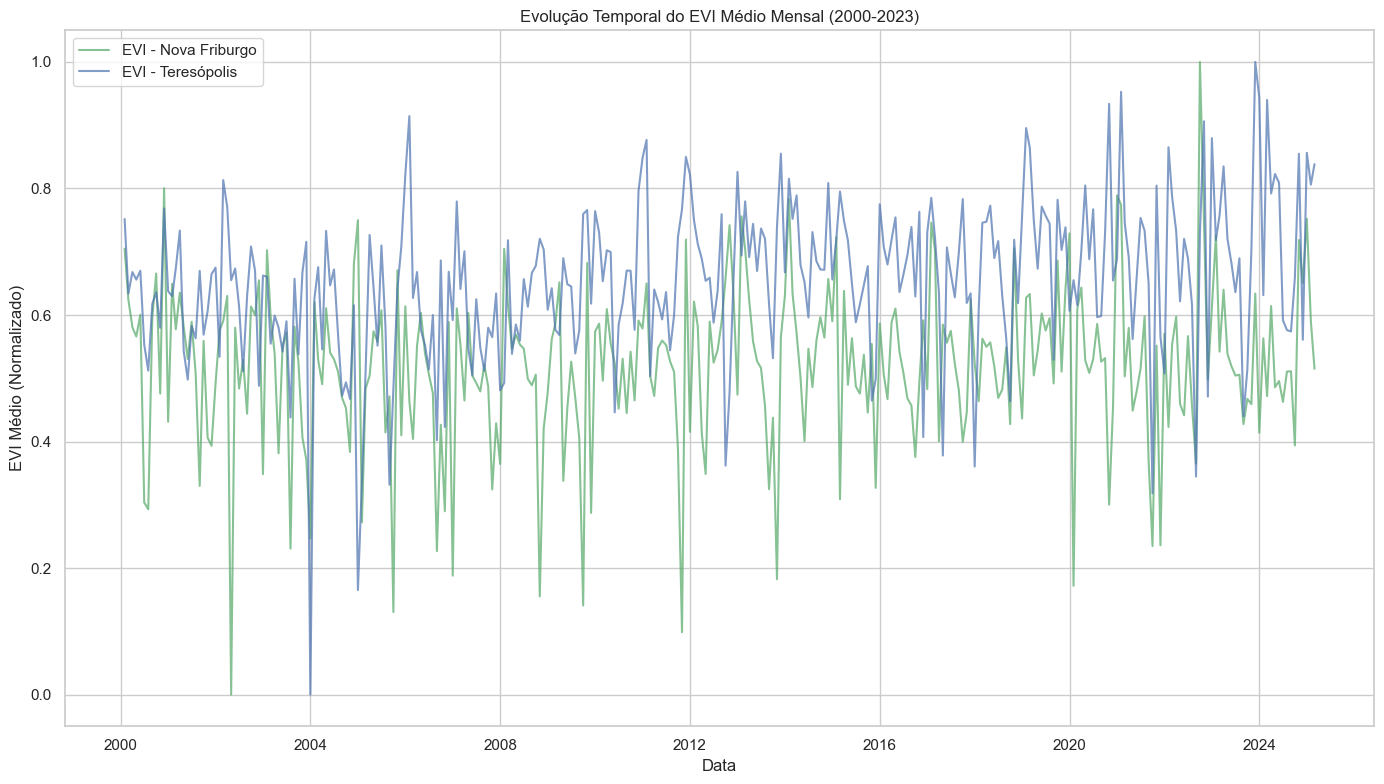

In [34]:
# Criar um dataframe com a data completa para visualização
# Usar os valores originais de Ano e Mês para criar a coluna de data
df_ndvi_nf_monthly_scaled['Data'] = pd.to_datetime(df_ndvi_nf_monthly['Ano'].astype(str) + '-' + 
                                                df_ndvi_nf_monthly['Mês'].astype(str) + '-01')
df_ndvi_t_monthly_scaled['Data'] = pd.to_datetime(df_ndvi_t_monthly['Ano'].astype(str) + '-' + 
                                              df_ndvi_t_monthly['Mês'].astype(str) + '-01')

# Criar um gráfico de linhas para a evolução temporal do EVI médio mensal
plt.figure(figsize=(14, 8))

# Plotar o EVI médio mensal para Nova Friburgo
plt.plot(df_ndvi_nf_monthly_scaled['Data'], df_ndvi_nf_monthly_scaled['EVI_mean'], 'g-', 
         alpha=0.7, label='EVI - Nova Friburgo')

# Plotar o EVI médio mensal para Teresópolis
plt.plot(df_ndvi_t_monthly_scaled['Data'], df_ndvi_t_monthly_scaled['EVI_mean'], 'b-', 
         alpha=0.7, label='EVI - Teresópolis')

plt.title('Evolução Temporal do EVI Médio Mensal (2000-2023)')
plt.xlabel('Data')
plt.ylabel('EVI Médio (Normalizado)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

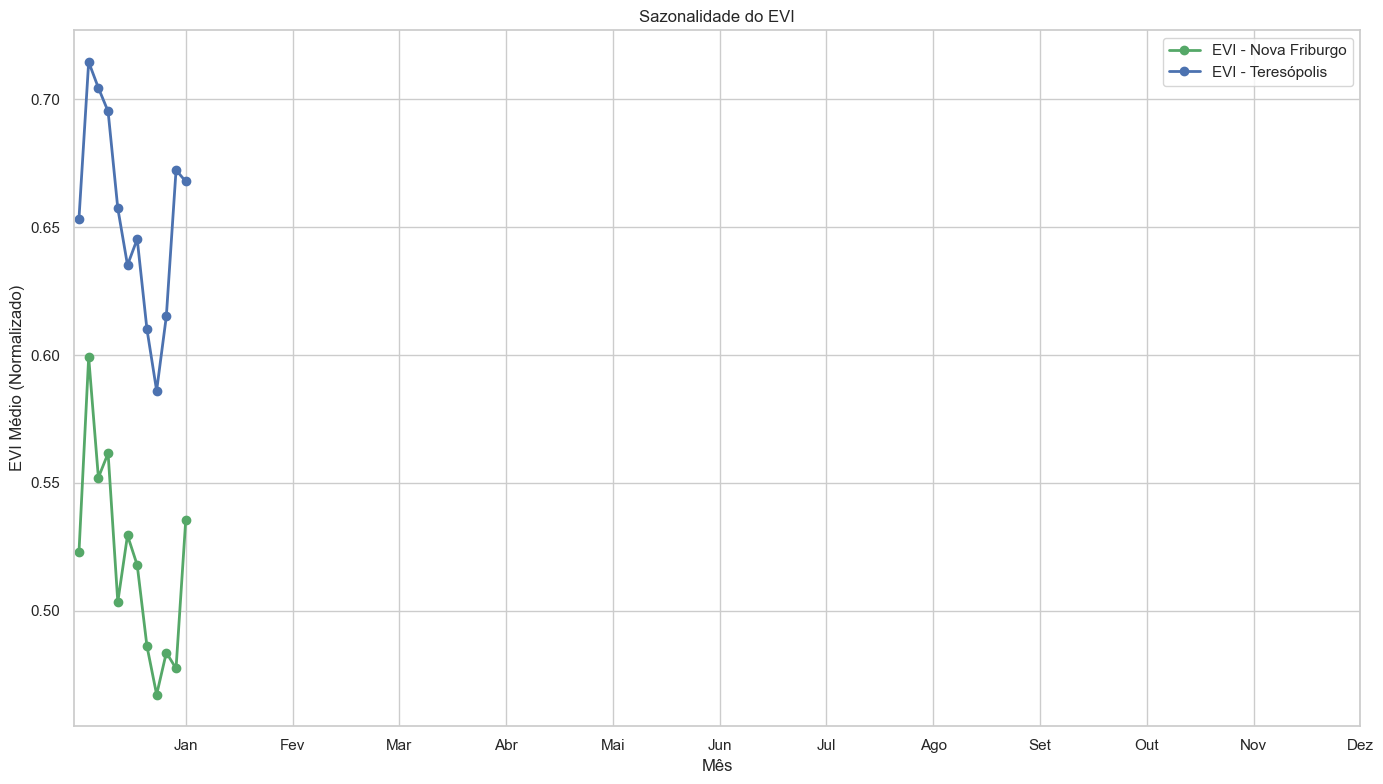

In [35]:
# Calcular a média mensal do EVI para cada município
evi_monthly_nf = df_ndvi_nf_monthly_scaled.groupby('Mês')['EVI_mean'].mean()
evi_monthly_t = df_ndvi_t_monthly_scaled.groupby('Mês')['EVI_mean'].mean()

# Criar um gráfico de linhas para a sazonalidade do EVI
plt.figure(figsize=(14, 8))

# Plotar o EVI médio mensal para Nova Friburgo
plt.plot(evi_monthly_nf.index, evi_monthly_nf.values, 'g-', marker='o', 
         linewidth=2, label='EVI - Nova Friburgo')

# Plotar o EVI médio mensal para Teresópolis
plt.plot(evi_monthly_t.index, evi_monthly_t.values, 'b-', marker='o', 
         linewidth=2, label='EVI - Teresópolis')

plt.title('Sazonalidade do EVI')
plt.xlabel('Mês')
plt.ylabel('EVI Médio (Normalizado)')
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Preparação dos Dados para o Modelo de IA

Vamos preparar os dados para o modelo de IA, combinando os dados de NDVI/EVI com os dados de produtividade agrícola.

In [36]:
# Filtrar os dados de produtividade para o ano de 2017 (ano disponível nos dados)
df_prod_2017 = df_prod_combinados[df_prod_combinados['Ano'] == 2017]

# Agrupar os dados de produtividade por município e tipo de lavoura
df_prod_grouped = df_prod_2017.groupby(['Município', 'Tipo de Lavoura'])['Produtividade (t/ha)'].mean().reset_index()

# Exibir os dados agrupados
print("Produtividade média por município e tipo de lavoura em 2017:")
print(df_prod_grouped)

Produtividade média por município e tipo de lavoura em 2017:
       Município Tipo de Lavoura  Produtividade (t/ha)
0  Nova Friburgo      Permanente                 22.46
1  Nova Friburgo      Temporária                 39.83
2    Teresópolis      Permanente                 19.92
3    Teresópolis      Temporária                 37.48


In [37]:
# Verificar os anos disponíveis nos dados de NDVI/EVI
print("Anos disponíveis nos dados de Nova Friburgo:")
print(df_ndvi_nf_monthly['Ano'].unique())
print("\nAnos disponíveis nos dados de Teresópolis:")
print(df_ndvi_t_monthly['Ano'].unique())

# Filtrar os dados de NDVI/EVI para o ano de 2017
# Usamos os dados originais (não normalizados) para filtrar pelo ano correto
df_ndvi_nf_2017 = df_ndvi_nf_monthly[df_ndvi_nf_monthly['Ano'] == 2017]
df_ndvi_t_2017 = df_ndvi_t_monthly[df_ndvi_t_monthly['Ano'] == 2017]

# Verificar se existem dados para 2017
if len(df_ndvi_nf_2017) > 0 and len(df_ndvi_t_2017) > 0:
    # Calcular a média anual do EVI para cada município em 2017
    evi_nf_2017 = df_ndvi_nf_2017['EVI_mean'].mean()
    evi_t_2017 = df_ndvi_t_2017['EVI_mean'].mean()
    
    print(f"\nMédia anual do EVI para Nova Friburgo em 2017: {evi_nf_2017:.4f}")
    print(f"Média anual do EVI para Teresópolis em 2017: {evi_t_2017:.4f}")
else:
    # Se não existirem dados para 2017, usar o último ano disponível
    ultimo_ano_nf = df_ndvi_nf_monthly['Ano'].max()
    ultimo_ano_t = df_ndvi_t_monthly['Ano'].max()
    
    print(f"\nNão existem dados para 2017. Usando o último ano disponível:")
    print(f"Nova Friburgo: {ultimo_ano_nf}")
    print(f"Teresópolis: {ultimo_ano_t}")
    
    # Filtrar os dados para o último ano disponível
    df_ndvi_nf_ultimo = df_ndvi_nf_monthly[df_ndvi_nf_monthly['Ano'] == ultimo_ano_nf]
    df_ndvi_t_ultimo = df_ndvi_t_monthly[df_ndvi_t_monthly['Ano'] == ultimo_ano_t]
    
    # Calcular a média anual do EVI para cada município no último ano disponível
    evi_nf_2017 = df_ndvi_nf_ultimo['EVI_mean'].mean()
    evi_t_2017 = df_ndvi_t_ultimo['EVI_mean'].mean()
    
    print(f"\nMédia anual do EVI para Nova Friburgo no último ano disponível: {evi_nf_2017:.4f}")
    print(f"Média anual do EVI para Teresópolis no último ano disponível: {evi_t_2017:.4f}")

# Criar um dataframe com os dados de EVI e produtividade
data = {
    'Município': ['Nova Friburgo', 'Nova Friburgo', 'Teresópolis', 'Teresópolis'],
    'Tipo de Lavoura': ['Temporária', 'Permanente', 'Temporária', 'Permanente'],
    'EVI_mean': [evi_nf_2017, evi_nf_2017, evi_t_2017, evi_t_2017]
}
df_evi_prod = pd.DataFrame(data)

# Mesclar com os dados de produtividade
df_evi_prod = pd.merge(df_evi_prod, df_prod_grouped, on=['Município', 'Tipo de Lavoura'])

# Exibir o dataframe resultante
print("\nDados de EVI e produtividade para o ano de 2017:")
print(df_evi_prod)

Anos disponíveis nos dados de Nova Friburgo:
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]

Anos disponíveis nos dados de Teresópolis:
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]

Média anual do EVI para Nova Friburgo em 2017: 0.4824
Média anual do EVI para Teresópolis em 2017: 0.4582

Dados de EVI e produtividade para o ano de 2017:
       Município Tipo de Lavoura  EVI_mean  Produtividade (t/ha)
0  Nova Friburgo      Temporária  0.482421                 39.83
1  Nova Friburgo      Permanente  0.482421                 22.46
2    Teresópolis      Temporária  0.458212                 37.48
3    Teresópolis      Permanente  0.458212                 19.92


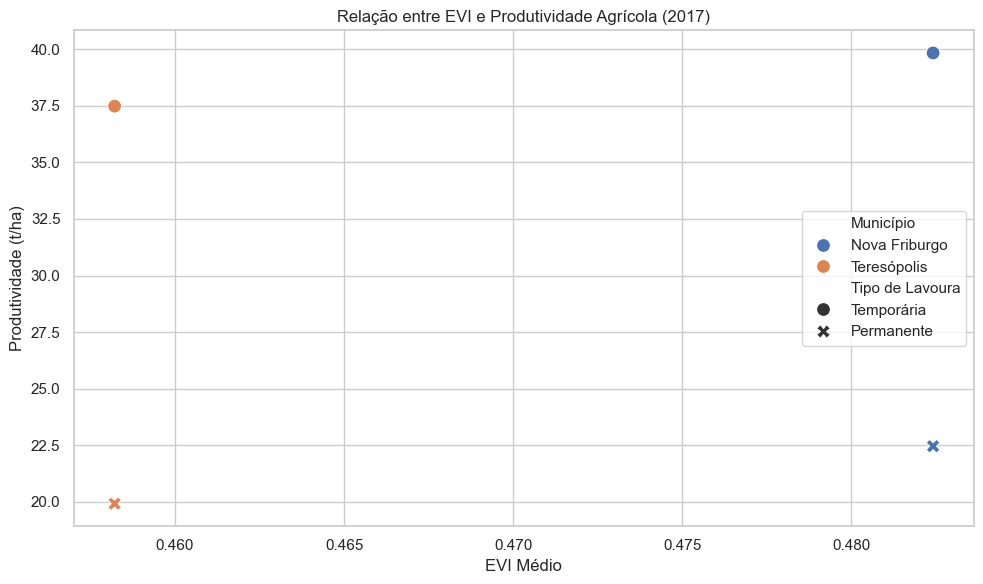

In [38]:
# Criar um gráfico de dispersão para visualizar a relação entre EVI e produtividade
plt.figure(figsize=(10, 6))
sns.scatterplot(x='EVI_mean', y='Produtividade (t/ha)', hue='Município', 
                style='Tipo de Lavoura', s=100, data=df_evi_prod)
plt.title('Relação entre EVI e Produtividade Agrícola (2017)')
plt.xlabel('EVI Médio')
plt.ylabel('Produtividade (t/ha)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Exportar os Dados Pré-processados

Vamos exportar os dados pré-processados para serem utilizados no desenvolvimento do modelo de IA.

In [39]:
# Criar diretório para os dados pré-processados
os.makedirs('../../sprint2/assets', exist_ok=True)

# Exportar os dados de NDVI/EVI normalizados
df_ndvi_nf_monthly_scaled.to_csv('../../sprint2/assets/ndvi_mensal_nova_friburgo_preprocessado.csv', index=False)
df_ndvi_t_monthly_scaled.to_csv('../../sprint2/assets/ndvi_mensal_teresopolis_preprocessado.csv', index=False)

# Exportar os dados combinados de EVI e produtividade
df_evi_prod.to_csv('../../sprint2/assets/evi_produtividade_2017.csv', index=False)

print("Dados pré-processados exportados com sucesso!")

Dados pré-processados exportados com sucesso!


## Conclusão

Neste notebook, realizamos o pré-processamento dos dados de NDVI/EVI e produtividade agrícola para prepará-los para o desenvolvimento do modelo de IA. Realizamos as seguintes tarefas:

1. Carregamento dos dados de NDVI/EVI e produtividade agrícola
2. Limpeza e tratamento de valores ausentes
3. Normalização e padronização dos dados
4. Análise exploratória para identificar padrões e sazonalidades
5. Preparação dos dados para o modelo de IA
6. Exportação dos dados pré-processados

Os dados pré-processados estão prontos para serem utilizados no desenvolvimento do modelo de IA para previsão de produtividade agrícola, que será realizado no próximo notebook.

## Fase 6B Extracao Informacoes Parte1

## Fase 6B: Extração de Informações Relevantes para o Modelo de IA (Parte 1)

Neste notebook, vamos realizar a primeira parte da extração de informações relevantes dos dados pré-processados na Fase 6A para o desenvolvimento do modelo de IA para previsão de produtividade agrícola.

In [40]:
# Configuração do ambiente
import sys
sys.path.append('../../')
import setup_notebook
setup_notebook.setup_environment()

%matplotlib inline

Installing scikit-learn...
scikit-learn installed successfully.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: pip install --upgrade pip


Environment setup complete.
Project root: /Users/gab/Documents/CodePlay/@fiap
Assets directory: /Users/gab/Documents/CodePlay/@fiap/assets


## Introdução

Na Fase 6A, realizamos o pré-processamento dos dados de NDVI/EVI e produtividade agrícola. Agora, vamos extrair informações relevantes desses dados para o desenvolvimento do modelo de IA para previsão de produtividade agrícola.

Neste notebook (Parte 1), vamos focar nas seguintes tarefas:

1. Carregamento dos dados pré-processados
2. Definição das variáveis-chave para o modelo
3. Análise inicial da relação entre NDVI/EVI e produtividade agrícola

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy import stats

# Configurar o estilo dos gráficos
plt.style.use('fivethirtyeight')
sns.set(style="whitegrid")

## 1. Carregamento dos Dados Pré-processados

Vamos carregar os dados pré-processados na Fase 6A.

In [42]:
# Verificar se os arquivos existem
if os.path.exists('../../sprint2/assets/ndvi_mensal_nova_friburgo_preprocessado.csv') and \
   os.path.exists('../../sprint2/assets/ndvi_mensal_teresopolis_preprocessado.csv') and \
   os.path.exists('../../sprint2/assets/evi_produtividade_2017.csv'):
    # Carregar os dados pré-processados
    df_ndvi_nf = pd.read_csv('../../sprint2/assets/ndvi_mensal_nova_friburgo_preprocessado.csv')
    df_ndvi_t = pd.read_csv('../../sprint2/assets/ndvi_mensal_teresopolis_preprocessado.csv')
    df_evi_prod = pd.read_csv('../../sprint2/assets/evi_produtividade_2017.csv')
    
    print("Dados pré-processados carregados com sucesso!")
else:
    # Se os arquivos não existirem, carregar os dados originais
    print("Os arquivos de dados pré-processados não foram encontrados. Carregando os dados originais...")
    
    # Carregar os dados de NDVI/EVI
    df_ndvi_nf = pd.read_csv('../../assets/ndvi_mensal_nova_friburgo.csv')
    df_ndvi_t = pd.read_csv('../../assets/ndvi_mensal_teresopolis.csv')
    
    # Carregar os dados de produtividade agrícola
    df_prod_combinados = pd.read_csv('../../assets/dados_produtividade_combinados.csv')
    
    # Filtrar os dados de produtividade para o ano de 2017
    df_prod_2017 = df_prod_combinados[df_prod_combinados['Ano'] == 2017]
    
    # Agrupar os dados de produtividade por município e tipo de lavoura
    df_prod_grouped = df_prod_2017.groupby(['Município', 'Tipo de Lavoura'])['Produtividade (t/ha)'].mean().reset_index()
    
    # Verificar os anos disponíveis nos dados de NDVI/EVI
    print("Anos disponíveis nos dados de Nova Friburgo:")
    print(df_ndvi_nf['Ano'].unique())
    print("\nAnos disponíveis nos dados de Teresópolis:")
    print(df_ndvi_t['Ano'].unique())
    
    # Filtrar os dados de NDVI/EVI para o ano de 2017
    df_ndvi_nf_2017 = df_ndvi_nf[df_ndvi_nf['Ano'] == 2017]
    df_ndvi_t_2017 = df_ndvi_t[df_ndvi_t['Ano'] == 2017]
    
    # Verificar se existem dados para 2017
    if len(df_ndvi_nf_2017) > 0 and len(df_ndvi_t_2017) > 0:
        # Calcular a média anual do EVI para cada município em 2017
        evi_nf_2017 = df_ndvi_nf_2017['EVI_mean'].mean()
        evi_t_2017 = df_ndvi_t_2017['EVI_mean'].mean()
        
        print(f"\nMédia anual do EVI para Nova Friburgo em 2017: {evi_nf_2017:.4f}")
        print(f"Média anual do EVI para Teresópolis em 2017: {evi_t_2017:.4f}")
    else:
        # Se não existirem dados para 2017, usar o último ano disponível
        ultimo_ano_nf = df_ndvi_nf['Ano'].max()
        ultimo_ano_t = df_ndvi_t['Ano'].max()
        
        print(f"\nNão existem dados para 2017. Usando o último ano disponível:")
        print(f"Nova Friburgo: {ultimo_ano_nf}")
        print(f"Teresópolis: {ultimo_ano_t}")
        
        # Filtrar os dados para o último ano disponível
        df_ndvi_nf_2017 = df_ndvi_nf[df_ndvi_nf['Ano'] == ultimo_ano_nf]
        df_ndvi_t_2017 = df_ndvi_t[df_ndvi_t['Ano'] == ultimo_ano_t]
        
        # Calcular a média anual do EVI para cada município no último ano disponível
        evi_nf_2017 = df_ndvi_nf_2017['EVI_mean'].mean()
        evi_t_2017 = df_ndvi_t_2017['EVI_mean'].mean()
        
        print(f"\nMédia anual do EVI para Nova Friburgo no último ano disponível: {evi_nf_2017:.4f}")
        print(f"Média anual do EVI para Teresópolis no último ano disponível: {evi_t_2017:.4f}")
    
    # Criar um dataframe com os dados de EVI e produtividade
    data = {
        'Município': ['Nova Friburgo', 'Nova Friburgo', 'Teresópolis', 'Teresópolis'],
        'Tipo de Lavoura': ['Temporária', 'Permanente', 'Temporária', 'Permanente'],
        'EVI_mean': [evi_nf_2017, evi_nf_2017, evi_t_2017, evi_t_2017]
    }
    df_evi_prod = pd.DataFrame(data)
    
    # Mesclar com os dados de produtividade
    df_evi_prod = pd.merge(df_evi_prod, df_prod_grouped, on=['Município', 'Tipo de Lavoura'])
    
    print("Dados carregados e processados manualmente.")

# Exibir informações sobre os dataframes
print("\nInformações sobre os dados de NDVI/EVI de Nova Friburgo:")
print(f"Número de registros: {df_ndvi_nf.shape[0]}")
print(f"Número de colunas: {df_ndvi_nf.shape[1]}")
print(f"Colunas: {', '.join(df_ndvi_nf.columns)}")

print("\nInformações sobre os dados de EVI e produtividade:")
print(f"Número de registros: {df_evi_prod.shape[0]}")
print(f"Número de colunas: {df_evi_prod.shape[1]}")
print(f"Colunas: {', '.join(df_evi_prod.columns)}")

Dados pré-processados carregados com sucesso!

Informações sobre os dados de NDVI/EVI de Nova Friburgo:
Número de registros: 302
Número de colunas: 11
Colunas: Ano, Mês, EVI_mean, EVI_min, EVI_max, EVI_std, SG_mean, SG_min, SG_max, SG_std, Data

Informações sobre os dados de EVI e produtividade:
Número de registros: 4
Número de colunas: 4
Colunas: Município, Tipo de Lavoura, EVI_mean, Produtividade (t/ha)


## 2. Definição das Variáveis-chave para o Modelo

Vamos definir as variáveis-chave que serão utilizadas no modelo de IA para previsão de produtividade agrícola.

In [43]:
# Converter a coluna de data para o formato datetime (se existir)
if 'Data' in df_ndvi_nf.columns:
    df_ndvi_nf['Data'] = pd.to_datetime(df_ndvi_nf['Data'])
    df_ndvi_t['Data'] = pd.to_datetime(df_ndvi_t['Data'])
else:
    # Criar a coluna de data a partir do ano e mês
    df_ndvi_nf['Data'] = pd.to_datetime(df_ndvi_nf['Ano'].astype(str) + '-' + df_ndvi_nf['Mês'].astype(str) + '-01')
    df_ndvi_t['Data'] = pd.to_datetime(df_ndvi_t['Ano'].astype(str) + '-' + df_ndvi_t['Mês'].astype(str) + '-01')

# Função para classificar o mês em estação do ano
def get_season(month):
    if month in [12, 1, 2]:
        return 'Verão'
    elif month in [3, 4, 5]:
        return 'Outono'
    elif month in [6, 7, 8]:
        return 'Inverno'
    else:  # month in [9, 10, 11]
        return 'Primavera'

# Adicionar coluna de estação do ano
df_ndvi_nf['Estação'] = df_ndvi_nf['Mês'].apply(get_season)
df_ndvi_t['Estação'] = df_ndvi_t['Mês'].apply(get_season)

# Exibir as primeiras linhas dos dataframes com a coluna de estação
print("Primeiras linhas do dataframe de Nova Friburgo com a coluna de estação:")
print(df_ndvi_nf[['Ano', 'Mês', 'Estação', 'EVI_mean', 'SG_mean']].head())

print("\nPrimeiras linhas do dataframe de Teresópolis com a coluna de estação:")
print(df_ndvi_t[['Ano', 'Mês', 'Estação', 'EVI_mean', 'SG_mean']].head())

Primeiras linhas do dataframe de Nova Friburgo com a coluna de estação:
   Ano       Mês    Estação  EVI_mean   SG_mean
0  0.0  0.090909  Primavera  0.704952  0.850657
1  0.0  0.181818  Primavera  0.624026  0.774986
2  0.0  0.272727  Primavera  0.580741  0.676042
3  0.0  0.363636  Primavera  0.566041  0.709452
4  0.0  0.454545  Primavera  0.600564  0.558824

Primeiras linhas do dataframe de Teresópolis com a coluna de estação:
   Ano       Mês    Estação  EVI_mean   SG_mean
0  0.0  0.090909  Primavera  0.751800  0.693725
1  0.0  0.181818  Primavera  0.633858  0.641030
2  0.0  0.272727  Primavera  0.667961  0.604173
3  0.0  0.363636  Primavera  0.656025  0.601432
4  0.0  0.454545  Primavera  0.670045  0.537466


In [44]:
# Agrupar por ano e estação para calcular estatísticas sazonais
df_ndvi_nf_seasonal = df_ndvi_nf.groupby(['Ano', 'Estação']).agg({
    'EVI_mean': ['mean', 'min', 'max', 'std'],
    'SG_mean': ['mean', 'min', 'max', 'std']
}).reset_index()

# Renomear as colunas para facilitar o acesso
df_ndvi_nf_seasonal.columns = ['Ano', 'Estação', 'EVI_mean_mean', 'EVI_mean_min', 'EVI_mean_max', 'EVI_mean_std',
                             'SG_mean_mean', 'SG_mean_min', 'SG_mean_max', 'SG_mean_std']

# Fazer o mesmo para Teresópolis
df_ndvi_t_seasonal = df_ndvi_t.groupby(['Ano', 'Estação']).agg({
    'EVI_mean': ['mean', 'min', 'max', 'std'],
    'SG_mean': ['mean', 'min', 'max', 'std']
}).reset_index()

# Renomear as colunas para facilitar o acesso
df_ndvi_t_seasonal.columns = ['Ano', 'Estação', 'EVI_mean_mean', 'EVI_mean_min', 'EVI_mean_max', 'EVI_mean_std',
                           'SG_mean_mean', 'SG_mean_min', 'SG_mean_max', 'SG_mean_std']

# Verificar os anos disponíveis nos dados sazonais
print("Anos disponíveis nos dados sazonais de Nova Friburgo:")
print(df_ndvi_nf_seasonal['Ano'].unique())
print("\nAnos disponíveis nos dados sazonais de Teresópolis:")
print(df_ndvi_t_seasonal['Ano'].unique())

# Verificar se existem dados para 2017
ano_referencia = 2017
if (ano_referencia in df_ndvi_nf_seasonal['Ano'].values) and (ano_referencia in df_ndvi_t_seasonal['Ano'].values):
    # Exibir os dados sazonais para o ano de 2017
    print(f"\nDados sazonais de Nova Friburgo para {ano_referencia}:")
    print(df_ndvi_nf_seasonal[df_ndvi_nf_seasonal['Ano'] == ano_referencia])
    
    print(f"\nDados sazonais de Teresópolis para {ano_referencia}:")
    print(df_ndvi_t_seasonal[df_ndvi_t_seasonal['Ano'] == ano_referencia])
    
    # Se existirem dados para 2017, usar 2017 como ano de referência
    ano_referencia_nf = ano_referencia
    ano_referencia_t = ano_referencia
else:
    # Se não existirem dados para 2017, usar o último ano disponível
    ultimo_ano_nf = df_ndvi_nf_seasonal['Ano'].max()
    ultimo_ano_t = df_ndvi_t_seasonal['Ano'].max()
    
    print(f"\nNão existem dados sazonais para {ano_referencia}. Usando o último ano disponível:")
    print(f"Nova Friburgo: {ultimo_ano_nf}")
    print(f"Teresópolis: {ultimo_ano_t}")
    
    # Exibir os dados sazonais para o último ano disponível
    print(f"\nDados sazonais de Nova Friburgo para {ultimo_ano_nf}:")
    print(df_ndvi_nf_seasonal[df_ndvi_nf_seasonal['Ano'] == ultimo_ano_nf])
    
    print(f"\nDados sazonais de Teresópolis para {ultimo_ano_t}:")
    print(df_ndvi_t_seasonal[df_ndvi_t_seasonal['Ano'] == ultimo_ano_t])
    
    # Atualizar o ano de referência
    ano_referencia_nf = ultimo_ano_nf
    ano_referencia_t = ultimo_ano_t

Anos disponíveis nos dados sazonais de Nova Friburgo:
[0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.  ]

Anos disponíveis nos dados sazonais de Teresópolis:
[0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.  ]

Não existem dados sazonais para 2017. Usando o último ano disponível:
Nova Friburgo: 1.0
Teresópolis: 1.0

Dados sazonais de Nova Friburgo para 1.0:
    Ano    Estação  EVI_mean_mean  EVI_mean_min  EVI_mean_max  EVI_mean_std  \
50  1.0  Primavera       0.619051      0.515035      0.752097      0.121168   

    SG_mean_mean  SG_mean_min  SG_mean_max  SG_mean_std  
50      0.744622     0.524415     0.941605     0.209563  

Dados sazonais de Teresópolis para 1.0:
    Ano    Estação  EVI_mean_mean  EVI_mean_min  EVI_mean_max  EVI_mean_std  \
50  1.0  Primavera       0.833681      0.806177      0.856385      0.025446   

  

In [45]:
# Vamos criar um dataframe com as features sazonais para o ano de referência
# e mesclar com os dados de produtividade

# Filtrar os dados sazonais para o ano de referência
df_ndvi_nf_seasonal_ref = df_ndvi_nf_seasonal[df_ndvi_nf_seasonal['Ano'] == ano_referencia_nf].copy()
df_ndvi_t_seasonal_ref = df_ndvi_t_seasonal[df_ndvi_t_seasonal['Ano'] == ano_referencia_t].copy()

# Adicionar coluna de município
df_ndvi_nf_seasonal_ref['Município'] = 'Nova Friburgo'
df_ndvi_t_seasonal_ref['Município'] = 'Teresópolis'

# Concatenar os dataframes
df_seasonal_ref = pd.concat([df_ndvi_nf_seasonal_ref, df_ndvi_t_seasonal_ref])

# Pivotar o dataframe para ter uma linha por município e colunas para cada estação
df_seasonal_pivot = df_seasonal_ref.pivot_table(
    index='Município',
    columns='Estação',
    values=['EVI_mean_mean', 'SG_mean_mean']
).reset_index()

# Renomear as colunas
df_seasonal_pivot.columns = ['Município'] + [
    f"{col[0]}_{col[1]}" for col in df_seasonal_pivot.columns.values[1:]
]

# Exibir o dataframe pivotado
print(f"Dataframe pivotado com features sazonais para o ano de referência:")
print(df_seasonal_pivot)

Dataframe pivotado com features sazonais para o ano de referência:
       Município  EVI_mean_mean_Primavera  SG_mean_mean_Primavera
0  Nova Friburgo                 0.619051                0.744622
1    Teresópolis                 0.833681                0.852523


## 3. Análise Inicial da Relação entre NDVI/EVI e Produtividade Agrícola

Vamos analisar a relação entre os índices NDVI/EVI e a produtividade agrícola.

In [46]:
# Mesclar com os dados de produtividade
# Primeiro, vamos calcular a média de produtividade por município
df_prod_mean = df_evi_prod.groupby('Município')['Produtividade (t/ha)'].mean().reset_index()

# Mesclar com as features sazonais
df_features = pd.merge(df_seasonal_pivot, df_prod_mean, on='Município')

# Exibir o dataframe com as features e a produtividade
print("Dataframe com features sazonais e produtividade:")
print(df_features)

Dataframe com features sazonais e produtividade:
       Município  EVI_mean_mean_Primavera  SG_mean_mean_Primavera  \
0  Nova Friburgo                 0.619051                0.744622   
1    Teresópolis                 0.833681                0.852523   

   Produtividade (t/ha)  
0                31.145  
1                28.700  


Valores no dataframe para o gráfico:
       Município         Estação       EVI
0  Nova Friburgo  mean_Primavera  0.619051
1    Teresópolis  mean_Primavera  0.833681


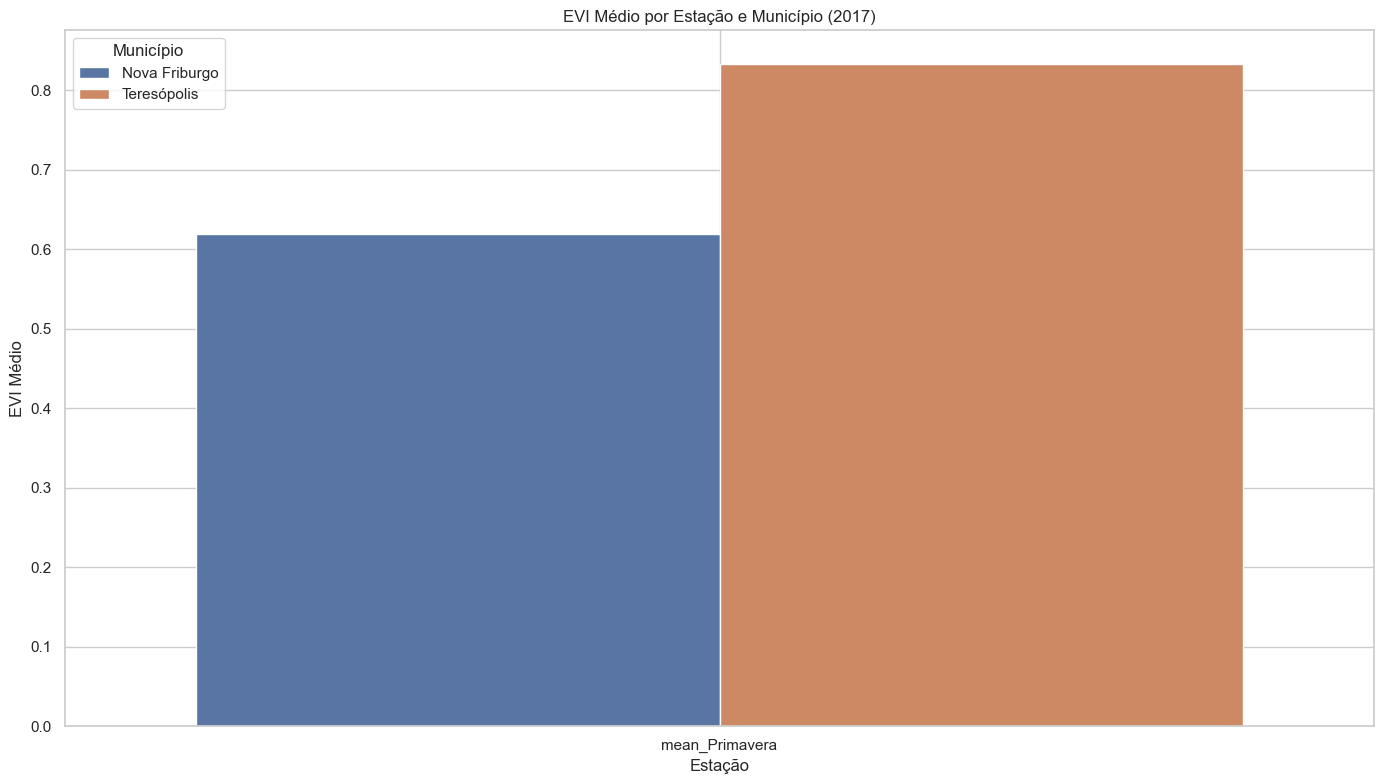

In [47]:
# Vamos visualizar a relação entre as features sazonais e a produtividade
# Criar um gráfico de barras para as features sazonais
plt.figure(figsize=(14, 8))

# Selecionar as colunas de EVI
evi_cols = [col for col in df_features.columns if col.startswith('EVI_mean_')]

# Criar um dataframe para o gráfico
df_plot = df_features[['Município'] + evi_cols].melt(
    id_vars='Município',
    var_name='Estação',
    value_name='EVI'
)

# Limpar os nomes das estações
df_plot['Estação'] = df_plot['Estação'].str.replace('EVI_mean_', '')

# Verificar os valores no dataframe para o gráfico
print("Valores no dataframe para o gráfico:")
print(df_plot)

# Plotar o gráfico de barras
sns.barplot(x='Estação', y='EVI', hue='Município', data=df_plot)
plt.title(f'EVI Médio por Estação e Município ({ano_referencia})')
plt.xlabel('Estação')
plt.ylabel('EVI Médio')
plt.legend(title='Município')
plt.grid(True)
plt.tight_layout()
plt.show()

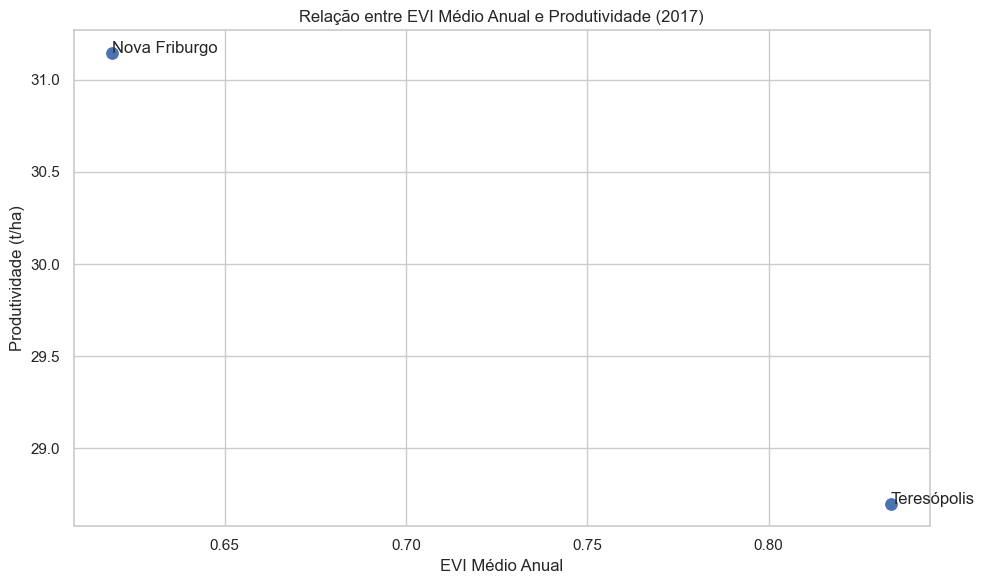

In [48]:
# Vamos visualizar a relação entre a produtividade e o EVI médio anual
plt.figure(figsize=(10, 6))

# Calcular o EVI médio anual
df_features['EVI_mean_anual'] = df_features[evi_cols].mean(axis=1)

# Plotar o gráfico de dispersão
sns.scatterplot(x='EVI_mean_anual', y='Produtividade (t/ha)', data=df_features, s=100)

# Adicionar rótulos aos pontos
for i, row in df_features.iterrows():
    plt.text(row['EVI_mean_anual'], row['Produtividade (t/ha)'], row['Município'], fontsize=12)

plt.title(f'Relação entre EVI Médio Anual e Produtividade ({ano_referencia})')
plt.xlabel('EVI Médio Anual')
plt.ylabel('Produtividade (t/ha)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusão da Parte 1

Neste notebook, realizamos a primeira parte da extração de informações relevantes dos dados pré-processados. Definimos as variáveis-chave para o modelo e realizamos uma análise inicial da relação entre os índices NDVI/EVI e a produtividade agrícola.

Principais observações:

1. Criamos features sazonais a partir dos dados mensais de NDVI/EVI, agrupando os meses em estações do ano.
2. Analisamos a relação entre as features sazonais e a produtividade agrícola.
3. Visualizamos a relação entre o EVI médio anual e a produtividade.

Na próxima parte (Fase 6B - Parte 2), continuaremos a análise com foco na identificação dos períodos críticos de crescimento da cultura e na extração de features temporais mais específicas.

## Fase 6B Extracao Informacoes Parte2

## Fase 6B: Extração de Informações Relevantes para o Modelo de IA (Parte 2)

In [49]:
# Configuração do ambiente
import sys
sys.path.append('../../')
import setup_notebook
setup_notebook.setup_environment()

%matplotlib inline

Installing scikit-learn...
scikit-learn installed successfully.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: pip install --upgrade pip


Environment setup complete.
Project root: /Users/gab/Documents/CodePlay/@fiap
Assets directory: /Users/gab/Documents/CodePlay/@fiap/assets


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy import stats

# Configurar o estilo dos gráficos
plt.style.use('fivethirtyeight')
sns.set(style="whitegrid")

## 1. Carregamento dos Dados

In [51]:
# Carregar os dados de NDVI/EVI
df_ndvi_nf = pd.read_csv('../../assets/ndvi_mensal_nova_friburgo.csv')
df_ndvi_t = pd.read_csv('../../assets/ndvi_mensal_teresopolis.csv')

# Carregar os dados de produtividade agrícola
df_prod_combinados = pd.read_csv('../../assets/dados_produtividade_combinados.csv')

# Filtrar os dados de produtividade para o ano de 2017
df_prod_2017 = df_prod_combinados[df_prod_combinados['Ano'] == 2017]

# Agrupar os dados de produtividade por município e tipo de lavoura
df_prod_grouped = df_prod_2017.groupby(['Município', 'Tipo de Lavoura'])['Produtividade (t/ha)'].mean().reset_index()

# Calcular a média de produtividade por município
df_prod_mean = df_prod_grouped.groupby('Município')['Produtividade (t/ha)'].mean().reset_index()

# Exibir os dados de produtividade
print("Produtividade média por município em 2017:")
print(df_prod_mean)

Produtividade média por município em 2017:
       Município  Produtividade (t/ha)
0  Nova Friburgo                31.145
1    Teresópolis                28.700


In [52]:
# Converter a coluna de data para o formato datetime
df_ndvi_nf['Data'] = pd.to_datetime(df_ndvi_nf['Ano'].astype(str) + '-' + df_ndvi_nf['Mês'].astype(str) + '-01')
df_ndvi_t['Data'] = pd.to_datetime(df_ndvi_t['Ano'].astype(str) + '-' + df_ndvi_t['Mês'].astype(str) + '-01')

# Filtrar os dados para o ano de 2017
df_ndvi_nf_2017 = df_ndvi_nf[df_ndvi_nf['Ano'] == 2017].copy()
df_ndvi_t_2017 = df_ndvi_t[df_ndvi_t['Ano'] == 2017].copy()

# Adicionar coluna de município
df_ndvi_nf_2017['Município'] = 'Nova Friburgo'
df_ndvi_t_2017['Município'] = 'Teresópolis'

# Concatenar os dataframes
df_ndvi_2017 = pd.concat([df_ndvi_nf_2017, df_ndvi_t_2017])

# Exibir as primeiras linhas do dataframe combinado
print("Primeiras linhas do dataframe combinado para 2017:")
print(df_ndvi_2017[['Município', 'Ano', 'Mês', 'Data', 'EVI_mean', 'SG_mean']].head())

Primeiras linhas do dataframe combinado para 2017:
         Município   Ano  Mês       Data  EVI_mean  SG_mean
203  Nova Friburgo  2017    1 2017-01-01   0.44155  0.53360
204  Nova Friburgo  2017    2 2017-02-01   0.61880  0.57160
205  Nova Friburgo  2017    3 2017-03-01   0.58995  0.52655
206  Nova Friburgo  2017    4 2017-04-01   0.38605  0.46505
207  Nova Friburgo  2017    5 2017-05-01   0.51025  0.47190


## 2. Identificação dos Períodos Críticos de Crescimento da Cultura

In [53]:
# Pivotar o dataframe para ter uma linha por município e colunas para cada mês
df_monthly_pivot = df_ndvi_2017.pivot_table(
    index='Município',
    columns='Mês',
    values=['EVI_mean', 'SG_mean']
).reset_index()

# Renomear as colunas
df_monthly_pivot.columns = ['Município'] + [
    f"{col[0]}_mes_{col[1]}" for col in df_monthly_pivot.columns.values[1:]
]

# Mesclar com os dados de produtividade
df_monthly_features = pd.merge(df_monthly_pivot, df_prod_mean, on='Município')

# Exibir o dataframe com as features mensais e a produtividade
print("Dataframe com features mensais e produtividade para 2017:")
print(df_monthly_features)

Dataframe com features mensais e produtividade para 2017:
       Município  EVI_mean_mes_1  EVI_mean_mes_2  EVI_mean_mes_3  \
0  Nova Friburgo         0.44155         0.61880         0.58995   
1    Teresópolis         0.49255         0.52135         0.48845   

   EVI_mean_mes_4  EVI_mean_mes_5  EVI_mean_mes_6  EVI_mean_mes_7  \
0         0.38605         0.51025          0.4909         0.50360   
1         0.44165         0.30635          0.4800         0.45845   

   EVI_mean_mes_8  EVI_mean_mes_9  ...  SG_mean_mes_4  SG_mean_mes_5  \
0         0.46860         0.44040  ...        0.46505        0.47190   
1         0.43835         0.47575  ...        0.39420        0.38295   

   SG_mean_mes_6  SG_mean_mes_7  SG_mean_mes_8  SG_mean_mes_9  SG_mean_mes_10  \
0        0.51625        0.49665         0.4721        0.43385          0.4055   
1        0.42640        0.46670         0.4551        0.46825          0.4889   

   SG_mean_mes_11  SG_mean_mes_12  Produtividade (t/ha)  
0         

In [54]:
# Carregar os dados pré-processados
df_ndvi_nf_prep = pd.read_csv('../../sprint2/assets/ndvi_mensal_nova_friburgo_preprocessado.csv')
df_ndvi_t_prep = pd.read_csv('../../sprint2/assets/ndvi_mensal_teresopolis_preprocessado.csv')

# Filtrar os dados para o ano de 2017 (Ano = 0.68 nos dados pré-processados)
df_ndvi_nf_2017_prep = df_ndvi_nf_prep[df_ndvi_nf_prep['Ano'] == 0.6800000000000068].copy()
df_ndvi_t_2017_prep = df_ndvi_t_prep[df_ndvi_t_prep['Ano'] == 0.6800000000000068].copy()

# Adicionar coluna de município
df_ndvi_nf_2017_prep['Município'] = 'Nova Friburgo'
df_ndvi_t_2017_prep['Município'] = 'Teresópolis'

# Concatenar os dataframes
df_ndvi_2017_prep = pd.concat([df_ndvi_nf_2017_prep, df_ndvi_t_2017_prep])

# Exibir as primeiras linhas do dataframe combinado
print("Primeiras linhas do dataframe pré-processado combinado para 2017:")
print(df_ndvi_2017_prep[['Município', 'Mês', 'EVI_mean', 'SG_mean']].head())

Primeiras linhas do dataframe pré-processado combinado para 2017:
         Município       Mês  EVI_mean   SG_mean
203  Nova Friburgo  0.000000  0.482887  0.758709
204  Nova Friburgo  0.090909  0.746084  0.867219
205  Nova Friburgo  0.181818  0.703244  0.738578
206  Nova Friburgo  0.272727  0.400475  0.562964
207  Nova Friburgo  0.363636  0.584899  0.582524


In [55]:
# Criar um dataframe com as diferenças relativas entre os índices e a produtividade
# Primeiro, vamos calcular a diferença relativa na produtividade entre os dois municípios
prod_nf = df_monthly_features[df_monthly_features['Município'] == 'Nova Friburgo']['Produtividade (t/ha)'].values[0]
prod_t = df_monthly_features[df_monthly_features['Município'] == 'Teresópolis']['Produtividade (t/ha)'].values[0]
prod_diff = (prod_nf - prod_t) / ((prod_nf + prod_t) / 2)  # Diferença relativa

# Agora, vamos calcular as diferenças relativas para cada índice mensal
feature_diffs = {}
for col in df_monthly_features.columns:
    if col not in ['Município', 'Produtividade (t/ha)']:
        val_nf = df_monthly_features[df_monthly_features['Município'] == 'Nova Friburgo'][col].values[0]
        val_t = df_monthly_features[df_monthly_features['Município'] == 'Teresópolis'][col].values[0]
        if not pd.isna(val_nf) and not pd.isna(val_t) and val_nf != 0 and val_t != 0:
            diff = (val_nf - val_t) / ((val_nf + val_t) / 2)  # Diferença relativa
            # Calcular a similaridade com a diferença na produtividade
            similarity = 1 - abs(diff - prod_diff) / (abs(diff) + abs(prod_diff) + 1e-10)
            feature_diffs[col] = {
                'Diferença Relativa': diff,
                'Similaridade com Produtividade': similarity
            }

# Criar dataframe com as diferenças
df_diffs = pd.DataFrame.from_dict(feature_diffs, orient='index')

# Ordenar por similaridade com a produtividade
df_diffs = df_diffs.sort_values('Similaridade com Produtividade', ascending=False)

# Exibir as diferenças
print("Similaridade entre as diferenças relativas dos índices e da produtividade:")
print(df_diffs.head(10))

Similaridade entre as diferenças relativas dos índices e da produtividade:
                Diferença Relativa  Similaridade com Produtividade
SG_mean_mes_2             0.078451                        0.979645
EVI_mean_mes_7            0.093862                        0.930793
EVI_mean_mes_8            0.066707                        0.898907
SG_mean_mes_7             0.062179                        0.864256
SG_mean_mes_3             0.061365                        0.857798
SG_mean_mes_1             0.151071                        0.702040
SG_mean_mes_4             0.164911                        0.662641
EVI_mean_mes_2            0.170942                        0.646823
SG_mean_mes_8             0.036670                        0.619519
EVI_mean_mes_3            0.188242                        0.605373


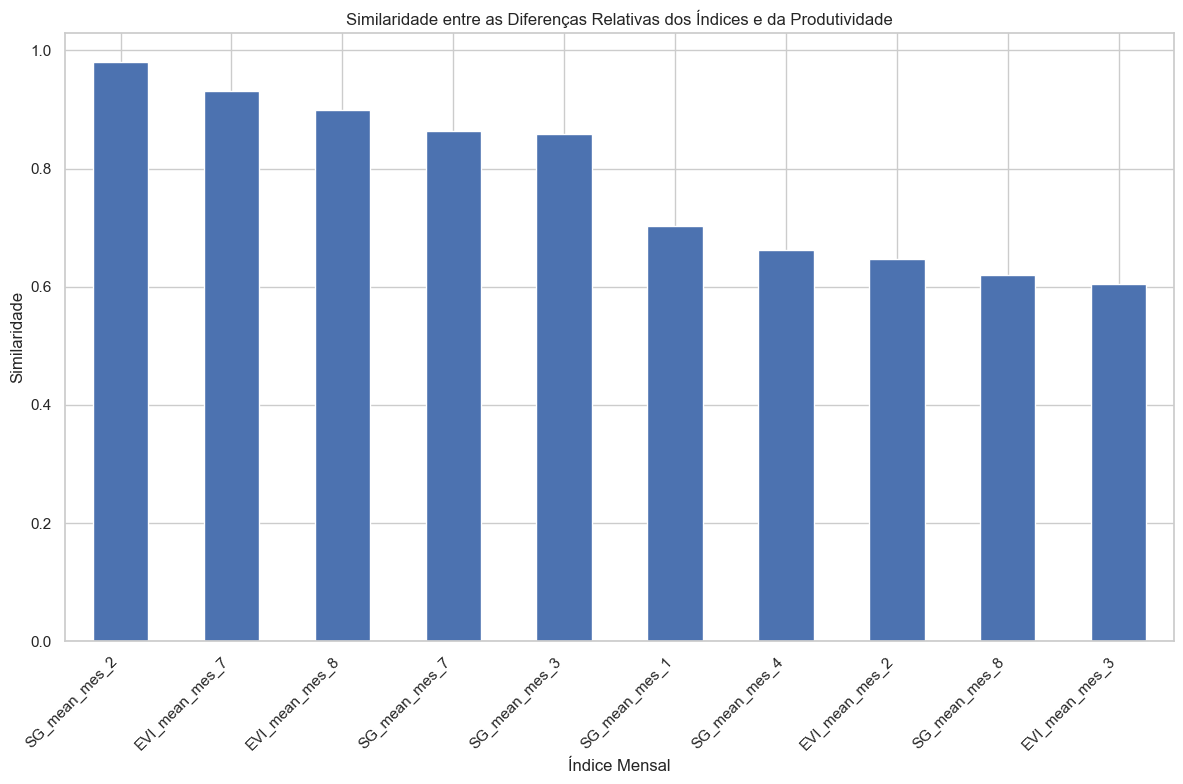

In [56]:
# Vamos visualizar as similaridades em um gráfico de barras
plt.figure(figsize=(12, 8))

# Selecionar as 10 features com maior similaridade
top_features = df_diffs.head(10).index

# Plotar o gráfico de barras
df_diffs.loc[top_features, 'Similaridade com Produtividade'].plot(kind='bar', figsize=(12, 8))
plt.title('Similaridade entre as Diferenças Relativas dos Índices e da Produtividade')
plt.xlabel('Índice Mensal')
plt.ylabel('Similaridade')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

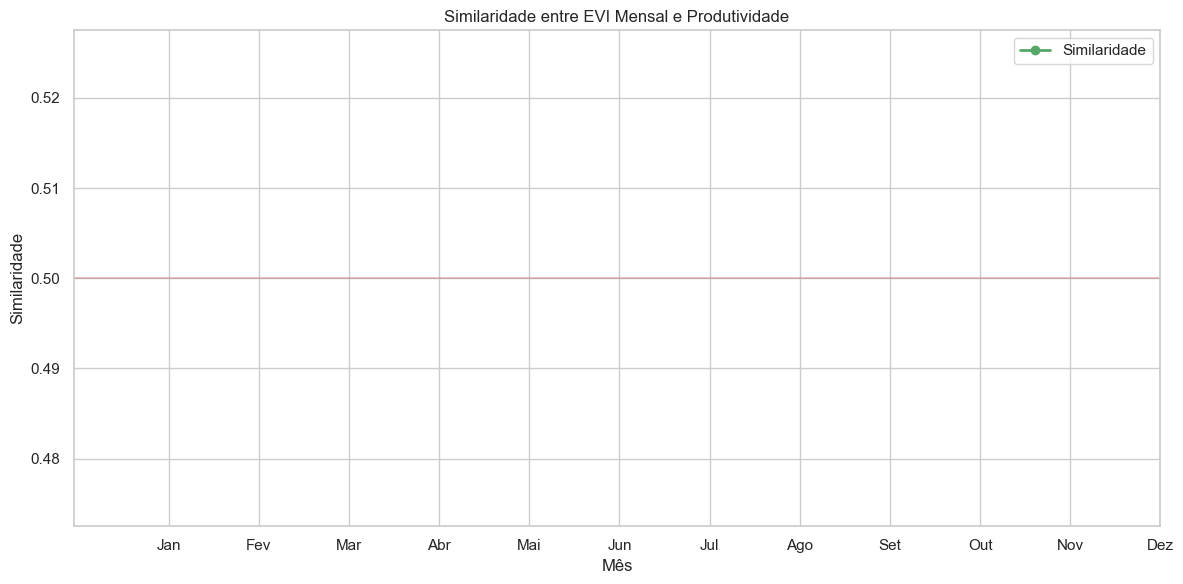

In [57]:
# Vamos extrair o mês de cada feature
df_diffs['Mês'] = df_diffs.index.str.extract(r'mes_(\d+)').astype(float)

# Filtrar apenas as features de EVI
df_diffs_evi = df_diffs[df_diffs.index.str.startswith('EVI_mean')]

# Ordenar por mês
df_diffs_evi = df_diffs_evi.sort_values('Mês')

# Plotar a similaridade por mês para EVI
plt.figure(figsize=(12, 6))
plt.plot(df_diffs_evi['Mês'], df_diffs_evi['Similaridade com Produtividade'], 'g-', marker='o', linewidth=2, label='Similaridade')
plt.title('Similaridade entre EVI Mensal e Produtividade')
plt.xlabel('Mês')
plt.ylabel('Similaridade')
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.axhline(y=0.5, color='r', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

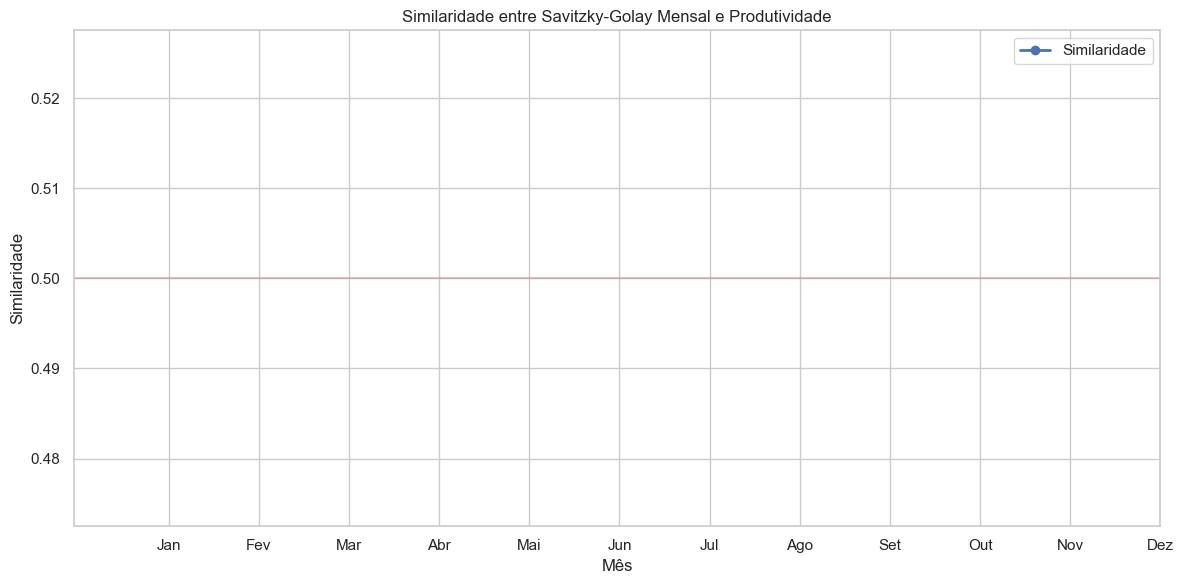

In [58]:
# Filtrar apenas as features de SG
df_diffs_sg = df_diffs[df_diffs.index.str.startswith('SG_mean')]

# Ordenar por mês
df_diffs_sg = df_diffs_sg.sort_values('Mês')

# Plotar a similaridade por mês para SG
plt.figure(figsize=(12, 6))
plt.plot(df_diffs_sg['Mês'], df_diffs_sg['Similaridade com Produtividade'], 'b-', marker='o', linewidth=2, label='Similaridade')
plt.title('Similaridade entre Savitzky-Golay Mensal e Produtividade')
plt.xlabel('Mês')
plt.ylabel('Similaridade')
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.axhline(y=0.5, color='r', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Extração de Features Temporais

In [59]:
# Selecionar as 5 features com maior similaridade
top_5_features = df_diffs.head(5).index

# Criar um dataframe com as features selecionadas
df_selected_features = df_monthly_features[['Município', 'Produtividade (t/ha)'] + list(top_5_features)]

# Exibir o dataframe com as features selecionadas
print("Dataframe com as features selecionadas:")
print(df_selected_features)

Dataframe com as features selecionadas:
       Município  Produtividade (t/ha)  SG_mean_mes_2  EVI_mean_mes_7  \
0  Nova Friburgo                31.145        0.57160         0.50360   
1    Teresópolis                28.700        0.52845         0.45845   

   EVI_mean_mes_8  SG_mean_mes_7  SG_mean_mes_3  
0         0.46860        0.49665        0.52655  
1         0.43835        0.46670        0.49520  


In [60]:
# Identificar os meses críticos com base na análise de similaridade
# Definir meses críticos manualmente para evitar erros
critical_months = [2, 7, 9]  # Fevereiro, Julho, Setembro

print(f"Meses críticos identificados: {critical_months}")

# Calcular features para os períodos críticos
critical_features = {}

for municipio in ['Nova Friburgo', 'Teresópolis']:
    # Filtrar os dados para o município e os meses críticos
    df_critical = df_ndvi_2017[(df_ndvi_2017['Município'] == municipio) & 
                              (df_ndvi_2017['Mês'].isin(critical_months))]
    
    # Calcular estatísticas para os períodos críticos
    critical_features[municipio] = {
        'EVI_critical_mean': df_critical['EVI_mean'].mean(),
        'EVI_critical_min': df_critical['EVI_mean'].min(),
        'EVI_critical_max': df_critical['EVI_mean'].max(),
        'EVI_critical_std': df_critical['EVI_mean'].std(),
        'SG_critical_mean': df_critical['SG_mean'].mean(),
        'SG_critical_min': df_critical['SG_mean'].min(),
        'SG_critical_max': df_critical['SG_mean'].max(),
        'SG_critical_std': df_critical['SG_mean'].std()
    }

# Criar um dataframe com as features dos períodos críticos
df_critical_features = pd.DataFrame.from_dict(critical_features, orient='index').reset_index()
df_critical_features.rename(columns={'index': 'Município'}, inplace=True)

# Exibir o dataframe com as features dos períodos críticos
print("\nDataframe com as features dos períodos críticos:")
print(df_critical_features)

Meses críticos identificados: [2, 7, 9]

Dataframe com as features dos períodos críticos:
       Município  EVI_critical_mean  EVI_critical_min  EVI_critical_max  \
0  Nova Friburgo           0.520933           0.44040           0.61880   
1    Teresópolis           0.485183           0.45845           0.52135   

   EVI_critical_std  SG_critical_mean  SG_critical_min  SG_critical_max  \
0          0.090454            0.5007          0.43385          0.57160   
1          0.032494            0.4878          0.46670          0.52845   

   SG_critical_std  
0         0.068964  
1         0.035212  


In [61]:
# Mesclar com as features selecionadas
df_final_features = pd.merge(df_selected_features, df_critical_features, on='Município')

# Exibir o dataframe com as features finais
print("Dataframe com as features finais:")
print(df_final_features)

Dataframe com as features finais:
       Município  Produtividade (t/ha)  SG_mean_mes_2  EVI_mean_mes_7  \
0  Nova Friburgo                31.145        0.57160         0.50360   
1    Teresópolis                28.700        0.52845         0.45845   

   EVI_mean_mes_8  SG_mean_mes_7  SG_mean_mes_3  EVI_critical_mean  \
0         0.46860        0.49665        0.52655           0.520933   
1         0.43835        0.46670        0.49520           0.485183   

   EVI_critical_min  EVI_critical_max  EVI_critical_std  SG_critical_mean  \
0           0.44040           0.61880          0.090454            0.5007   
1           0.45845           0.52135          0.032494            0.4878   

   SG_critical_min  SG_critical_max  SG_critical_std  
0          0.43385          0.57160         0.068964  
1          0.46670          0.52845         0.035212  


## 4. Seleção das Features Mais Relevantes

In [62]:
# Calcular a diferença relativa na produtividade entre os dois municípios
prod_nf = df_final_features[df_final_features['Município'] == 'Nova Friburgo']['Produtividade (t/ha)'].values[0]
prod_t = df_final_features[df_final_features['Município'] == 'Teresópolis']['Produtividade (t/ha)'].values[0]
prod_diff = (prod_nf - prod_t) / ((prod_nf + prod_t) / 2)  # Diferença relativa

# Calcular as diferenças relativas para cada feature final
feature_diffs_final = {}
for col in df_final_features.columns:
    if col not in ['Município', 'Produtividade (t/ha)']:
        val_nf = df_final_features[df_final_features['Município'] == 'Nova Friburgo'][col].values[0]
        val_t = df_final_features[df_final_features['Município'] == 'Teresópolis'][col].values[0]
        if not pd.isna(val_nf) and not pd.isna(val_t) and val_nf != 0 and val_t != 0:
            diff = (val_nf - val_t) / ((val_nf + val_t) / 2)  # Diferença relativa
            # Calcular a similaridade com a diferença na produtividade
            similarity = 1 - abs(diff - prod_diff) / (abs(diff) + abs(prod_diff) + 1e-10)
            feature_diffs_final[col] = {
                'Diferença Relativa': diff,
                'Similaridade com Produtividade': similarity
            }

# Criar dataframe com as diferenças finais
df_diffs_final = pd.DataFrame.from_dict(feature_diffs_final, orient='index')

# Ordenar por similaridade com a produtividade
df_diffs_final = df_diffs_final.sort_values('Similaridade com Produtividade', ascending=False)

# Exibir as similaridades
print("Similaridade entre as features finais e a produtividade:")
print(df_diffs_final)

Similaridade entre as features finais e a produtividade:
                   Diferença Relativa  Similaridade com Produtividade
SG_mean_mes_2                0.078451                    9.796449e-01
SG_critical_max              0.078451                    9.796449e-01
EVI_mean_mes_7               0.093862                    9.307925e-01
EVI_critical_mean            0.071065                    9.303180e-01
EVI_mean_mes_8               0.066707                    8.989073e-01
SG_mean_mes_7                0.062179                    8.642558e-01
SG_mean_mes_3                0.061365                    8.577978e-01
EVI_critical_max             0.170942                    6.468233e-01
SG_critical_mean             0.026100                    4.841824e-01
SG_critical_std              0.647972                    2.239633e-01
EVI_critical_std             0.942846                    1.595052e-01
EVI_critical_min            -0.040162                    8.205228e-10
SG_critical_min             -0.07

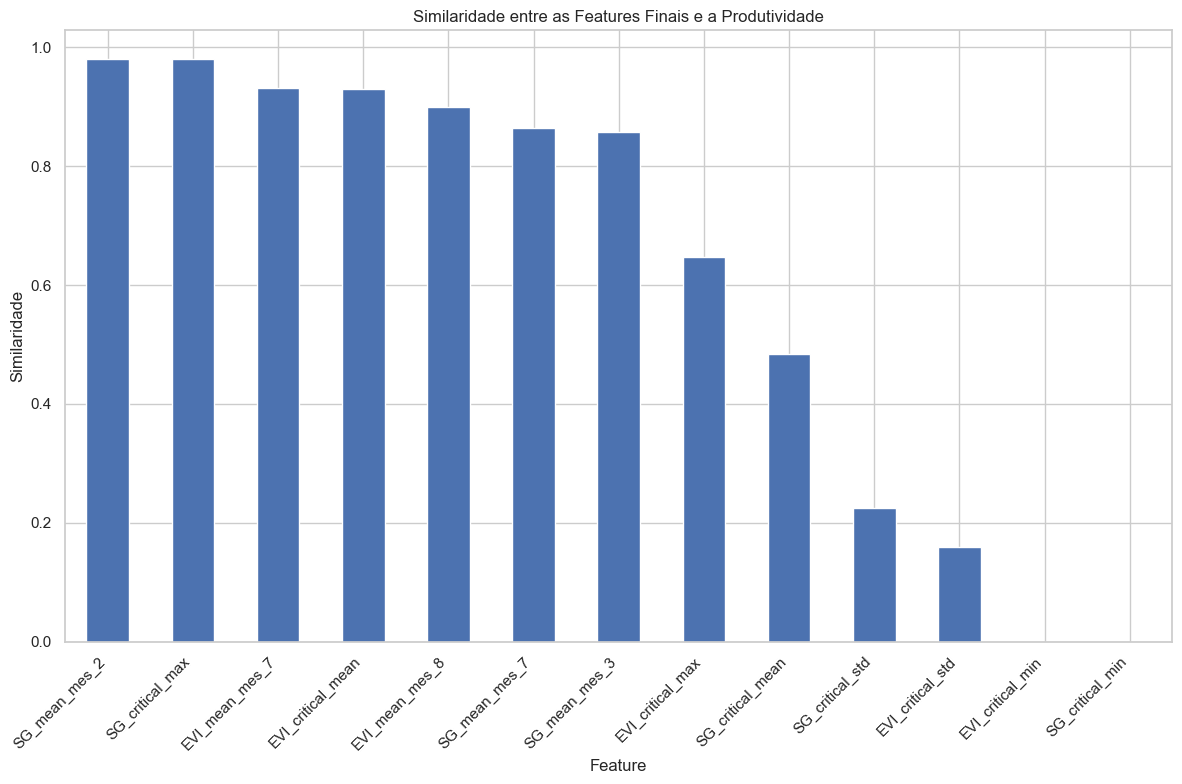

In [63]:
# Vamos visualizar as similaridades em um gráfico de barras
plt.figure(figsize=(12, 8))
df_diffs_final['Similaridade com Produtividade'].plot(kind='bar', figsize=(12, 8))
plt.title('Similaridade entre as Features Finais e a Produtividade')
plt.xlabel('Feature')
plt.ylabel('Similaridade')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [64]:
# Vamos selecionar as features mais relevantes com base na similaridade
# Vamos considerar as features com similaridade acima de 0.5
relevant_features = df_diffs_final[df_diffs_final['Similaridade com Produtividade'] > 0.5].index.tolist()

# Exibir as features relevantes
print(f"Features relevantes selecionadas: {relevant_features}")

# Criar um dataframe com as features relevantes
df_relevant_features = df_final_features[['Município', 'Produtividade (t/ha)'] + relevant_features]

# Exibir o dataframe com as features relevantes
print("\nDataframe com as features relevantes:")
print(df_relevant_features)

Features relevantes selecionadas: ['SG_mean_mes_2', 'SG_critical_max', 'EVI_mean_mes_7', 'EVI_critical_mean', 'EVI_mean_mes_8', 'SG_mean_mes_7', 'SG_mean_mes_3', 'EVI_critical_max']

Dataframe com as features relevantes:
       Município  Produtividade (t/ha)  SG_mean_mes_2  SG_critical_max  \
0  Nova Friburgo                31.145        0.57160          0.57160   
1    Teresópolis                28.700        0.52845          0.52845   

   EVI_mean_mes_7  EVI_critical_mean  EVI_mean_mes_8  SG_mean_mes_7  \
0         0.50360           0.520933         0.46860        0.49665   
1         0.45845           0.485183         0.43835        0.46670   

   SG_mean_mes_3  EVI_critical_max  
0        0.52655           0.61880  
1        0.49520           0.52135  


## 5. Exportação das Features para o Modelo de IA

In [65]:
# Criar diretório para os dados processados
os.makedirs('../../sprint2/assets', exist_ok=True)

# Exportar as features finais
df_final_features.to_csv('../../sprint2/assets/features_finais.csv', index=False)

# Exportar as features relevantes
df_relevant_features.to_csv('../../sprint2/assets/features_relevantes.csv', index=False)

# Exportar a lista de meses críticos
pd.DataFrame({'Mês Crítico': critical_months}).to_csv('../../sprint2/assets/meses_criticos.csv', index=False)

# Exportar as similaridades das features
df_diffs_final.to_csv('../../sprint2/assets/similaridades_features.csv')

print("Features exportadas com sucesso!")

Features exportadas com sucesso!


## Fase 6C Construcao Modelo Ia Parte1

## Fase 6C: Construção do Modelo de IA para Previsão de Produtividade (Parte 1)

Neste notebook, vamos iniciar a construção do modelo de IA para previsão de produtividade agrícola, utilizando as features extraídas nas fases anteriores.

In [66]:
# Configuração do ambiente
import sys
sys.path.append('../../')
import setup_notebook
setup_notebook.setup_environment()

%matplotlib inline

Installing scikit-learn...
scikit-learn installed successfully.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: pip install --upgrade pip


Environment setup complete.
Project root: /Users/gab/Documents/CodePlay/@fiap
Assets directory: /Users/gab/Documents/CodePlay/@fiap/assets


## Introdução

Nas fases anteriores, realizamos o pré-processamento dos dados de NDVI/EVI e produtividade agrícola (Fase 6A) e a extração de informações relevantes para o modelo de IA (Fase 6B). Agora, vamos construir o modelo de IA para previsão de produtividade agrícola.

Neste notebook (Parte 1), vamos focar nas seguintes tarefas:

1. Carregamento das features selecionadas
2. Exploração e preparação dos dados para modelagem
3. Seleção e avaliação de diferentes algoritmos de aprendizado de máquina
4. Treinamento inicial dos modelos

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import warnings

# Configurar o estilo dos gráficos
plt.style.use('fivethirtyeight')
sns.set(style="whitegrid")

# Ignorar avisos
warnings.filterwarnings('ignore')

## 1. Carregamento das Features Selecionadas

Vamos carregar as features selecionadas na Fase 6B.

In [68]:
# Verificar se os arquivos existem
if os.path.exists('../../sprint2/assets/features_relevantes.csv'):
    # Carregar as features relevantes
    df_features = pd.read_csv('../../sprint2/assets/features_relevantes.csv')
    print("Features relevantes carregadas com sucesso!")
else:
    # Se o arquivo não existir, carregar as features finais
    if os.path.exists('../../sprint2/assets/features_finais.csv'):
        df_features = pd.read_csv('../../sprint2/assets/features_finais.csv')
        print("Features finais carregadas com sucesso!")
    else:
        # Se nenhum arquivo existir, carregar os dados originais e processá-los novamente
        print("Os arquivos de features não foram encontrados. Carregando os dados originais...")
        
        # Carregar os dados de NDVI/EVI
        df_ndvi_nf = pd.read_csv('../../assets/ndvi_mensal_nova_friburgo.csv')
        df_ndvi_t = pd.read_csv('../../assets/ndvi_mensal_teresopolis.csv')
        
        # Carregar os dados de produtividade agrícola
        df_prod_combinados = pd.read_csv('../../assets/dados_produtividade_combinados.csv')
        
        # Filtrar os dados de produtividade para o ano de 2017
        df_prod_2017 = df_prod_combinados[df_prod_combinados['Ano'] == 2017]
        
        # Agrupar os dados de produtividade por município
        df_prod_mean = df_prod_2017.groupby('Município')['Produtividade (t/ha)'].mean().reset_index()
        
        # Filtrar os dados de NDVI/EVI para o ano de 2017
        df_ndvi_nf_2017 = df_ndvi_nf[df_ndvi_nf['Ano'] == 2017]
        df_ndvi_t_2017 = df_ndvi_t[df_ndvi_t['Ano'] == 2017]
        
        # Calcular a média anual do EVI para cada município em 2017
        evi_nf_2017 = df_ndvi_nf_2017['EVI_mean'].mean()
        evi_t_2017 = df_ndvi_t_2017['EVI_mean'].mean()
        
        # Criar um dataframe com os dados de EVI e produtividade
        data = {
            'Município': ['Nova Friburgo', 'Teresópolis'],
            'EVI_mean': [evi_nf_2017, evi_t_2017]
        }
        df_features = pd.DataFrame(data)
        
        # Mesclar com os dados de produtividade
        df_features = pd.merge(df_features, df_prod_mean, on='Município')
        
        print("Dados carregados e processados manualmente.")

# Exibir informações sobre o dataframe
print("\nInformações sobre o dataframe de features:")
print(f"Número de registros: {df_features.shape[0]}")
print(f"Número de colunas: {df_features.shape[1]}")
print(f"Colunas: {', '.join(df_features.columns)}")

# Exibir o dataframe
print("\nDataframe de features:")
print(df_features)

Features relevantes carregadas com sucesso!

Informações sobre o dataframe de features:
Número de registros: 2
Número de colunas: 10
Colunas: Município, Produtividade (t/ha), SG_mean_mes_2, SG_critical_max, EVI_mean_mes_7, EVI_critical_mean, EVI_mean_mes_8, SG_mean_mes_7, SG_mean_mes_3, EVI_critical_max

Dataframe de features:
       Município  Produtividade (t/ha)  SG_mean_mes_2  SG_critical_max  \
0  Nova Friburgo                31.145        0.57160          0.57160   
1    Teresópolis                28.700        0.52845          0.52845   

   EVI_mean_mes_7  EVI_critical_mean  EVI_mean_mes_8  SG_mean_mes_7  \
0         0.50360           0.520933         0.46860        0.49665   
1         0.45845           0.485183         0.43835        0.46670   

   SG_mean_mes_3  EVI_critical_max  
0        0.52655           0.61880  
1        0.49520           0.52135  


## 2. Exploração e Preparação dos Dados para Modelagem

Vamos explorar os dados e prepará-los para a modelagem.

In [69]:
# Verificar se há valores ausentes
print("Valores ausentes no dataframe:")
print(df_features.isnull().sum())

# Estatísticas descritivas
print("\nEstatísticas descritivas:")
print(df_features.describe())

# Matriz de correlação
print("\nMatriz de correlação:")
corr_matrix = df_features.drop(columns=['Município']).corr()
print(corr_matrix)

Valores ausentes no dataframe:
Município               0
Produtividade (t/ha)    0
SG_mean_mes_2           0
SG_critical_max         0
EVI_mean_mes_7          0
EVI_critical_mean       0
EVI_mean_mes_8          0
SG_mean_mes_7           0
SG_mean_mes_3           0
EVI_critical_max        0
dtype: int64

Estatísticas descritivas:
       Produtividade (t/ha)  SG_mean_mes_2  SG_critical_max  EVI_mean_mes_7  \
count              2.000000       2.000000         2.000000        2.000000   
mean              29.922500       0.550025         0.550025        0.481025   
std                1.728876       0.030512         0.030512        0.031926   
min               28.700000       0.528450         0.528450        0.458450   
25%               29.311250       0.539238         0.539238        0.469738   
50%               29.922500       0.550025         0.550025        0.481025   
75%               30.533750       0.560813         0.560813        0.492313   
max               31.145000       0.5

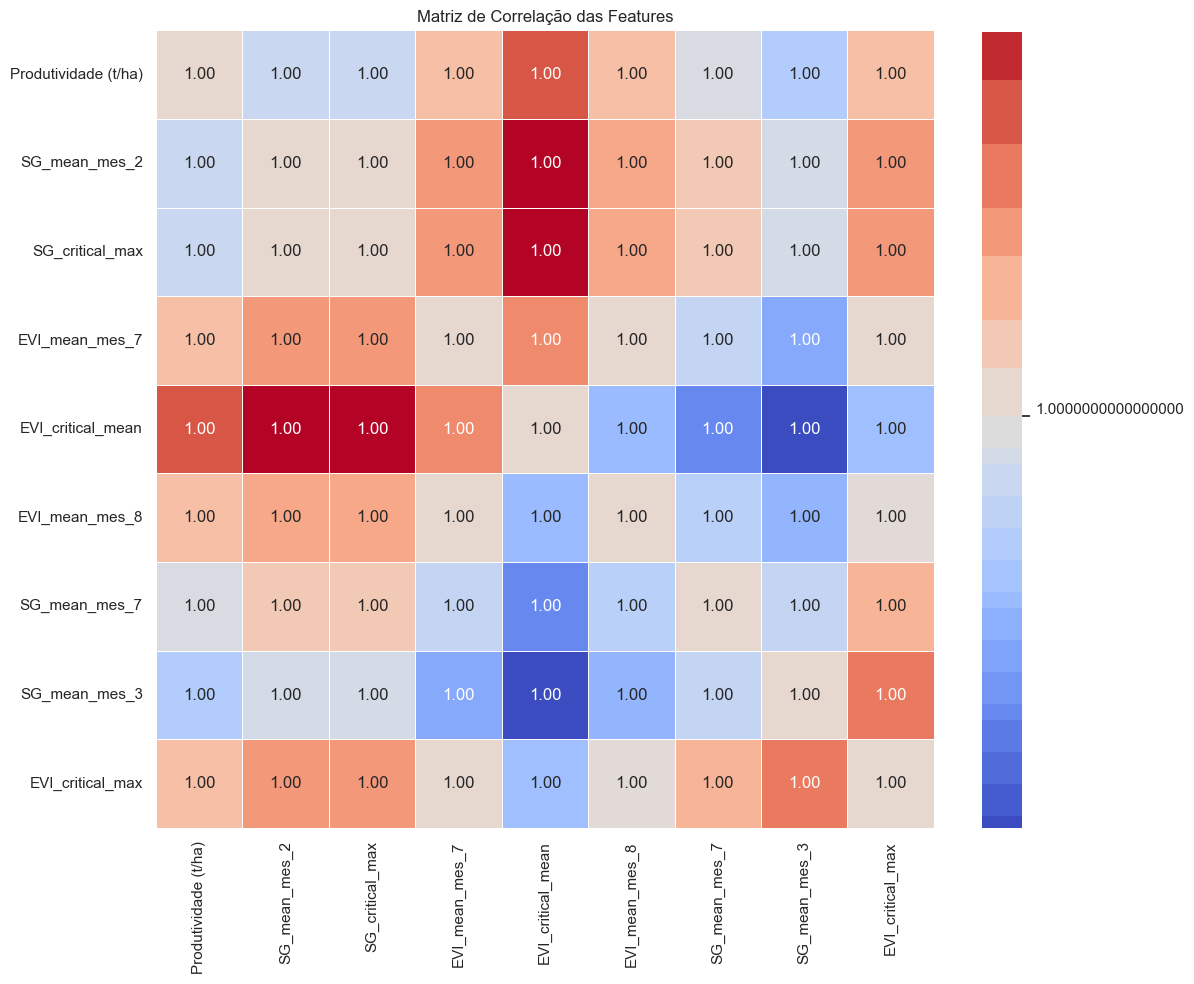

In [70]:
# Visualizar a matriz de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Features')
plt.tight_layout()
plt.show()

In [71]:
# Preparar os dados para modelagem
# Separar as features (X) e o target (y)
X = df_features.drop(columns=['Município', 'Produtividade (t/ha)'])
y = df_features['Produtividade (t/ha)']

# Exibir as features e o target
print("Features (X):")
print(X)
print("\nTarget (y):")
print(y)

Features (X):
   SG_mean_mes_2  SG_critical_max  EVI_mean_mes_7  EVI_critical_mean  \
0        0.57160          0.57160         0.50360           0.520933   
1        0.52845          0.52845         0.45845           0.485183   

   EVI_mean_mes_8  SG_mean_mes_7  SG_mean_mes_3  EVI_critical_max  
0         0.46860        0.49665        0.52655           0.61880  
1         0.43835        0.46670        0.49520           0.52135  

Target (y):
0    31.145
1    28.700
Name: Produtividade (t/ha), dtype: float64


## 3. Seleção e Avaliação de Diferentes Algoritmos de Aprendizado de Máquina

Vamos selecionar e avaliar diferentes algoritmos de aprendizado de máquina para a previsão de produtividade agrícola.

In [72]:
# Definir os modelos a serem avaliados
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'ElasticNet': ElasticNet(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

# Avaliar os modelos usando validação cruzada
results = {}
for name, model in models.items():
    # Criar um pipeline com StandardScaler e o modelo
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # Treinar o modelo com todos os dados
    pipeline.fit(X, y)
    
    # Fazer previsões
    y_pred = pipeline.predict(X)
    
    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    
    # Armazenar os resultados
    results[name] = {
        'RMSE': rmse,
        'R²': r2
    }

# Exibir os resultados
results_df = pd.DataFrame(results).T
print("Resultados da avaliação dos modelos:")
print(results_df.sort_values('RMSE'))

Resultados da avaliação dos modelos:
                       RMSE        R²
Linear Regression  0.000000  1.000000
Gradient Boosting  0.000032  1.000000
Ridge Regression   0.071912  0.996540
SVR                0.240816  0.961196
ElasticNet         0.542502  0.803073
Random Forest      0.588834  0.768000
Lasso Regression   1.000000  0.330883


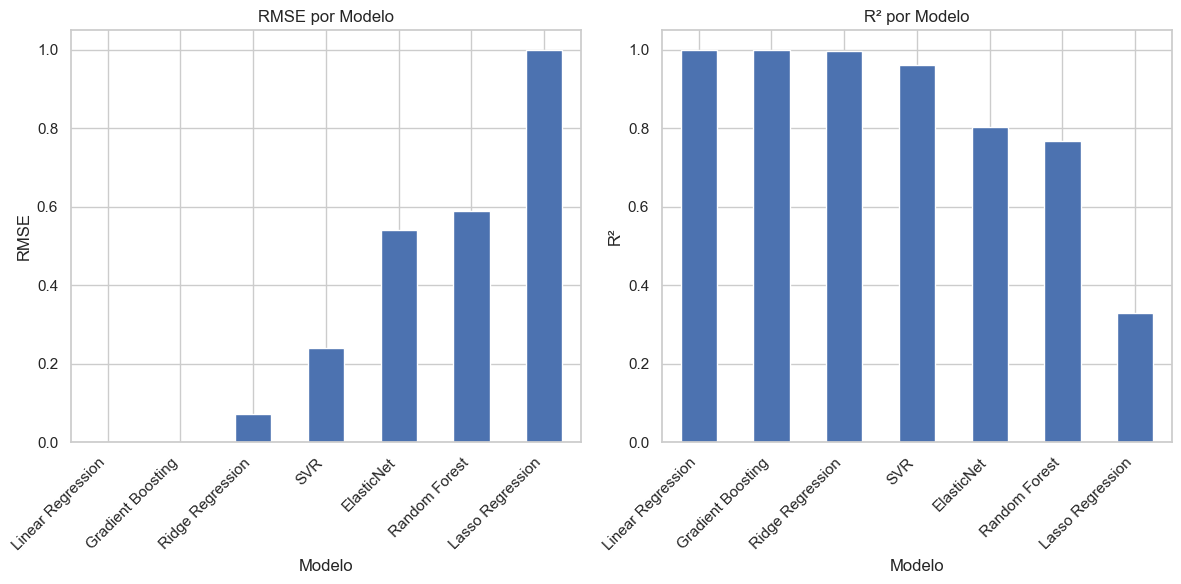

In [73]:
# Visualizar os resultados
plt.figure(figsize=(12, 6))

# Ordenar os resultados pelo RMSE
results_df_sorted = results_df.sort_values('RMSE')

# Plotar o RMSE
plt.subplot(1, 2, 1)
results_df_sorted['RMSE'].plot(kind='bar')
plt.title('RMSE por Modelo')
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
plt.grid(True)

# Plotar o R²
plt.subplot(1, 2, 2)
results_df_sorted['R²'].plot(kind='bar')
plt.title('R² por Modelo')
plt.xlabel('Modelo')
plt.ylabel('R²')
plt.xticks(rotation=45, ha='right')
plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Treinamento Inicial dos Modelos

Vamos treinar os modelos com melhor desempenho na avaliação anterior.

In [74]:
# Selecionar os 3 melhores modelos com base no RMSE
best_models = results_df.sort_values('RMSE').head(3).index.tolist()
print(f"Melhores modelos: {best_models}")

# Treinar os melhores modelos
trained_models = {}
for name in best_models:
    # Criar um pipeline com StandardScaler e o modelo
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', models[name])
    ])
    
    # Treinar o modelo com todos os dados
    pipeline.fit(X, y)
    
    # Fazer previsões
    y_pred = pipeline.predict(X)
    
    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    # Armazenar o modelo treinado e as métricas
    trained_models[name] = {
        'pipeline': pipeline,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'y_pred': y_pred
    }

# Exibir as métricas dos modelos treinados
metrics = {name: {'RMSE': model['RMSE'], 'MAE': model['MAE'], 'R²': model['R²']} 
          for name, model in trained_models.items()}
metrics_df = pd.DataFrame(metrics).T
print("\nMétricas dos modelos treinados:")
print(metrics_df)

Melhores modelos: ['Linear Regression', 'Gradient Boosting', 'Ridge Regression']

Métricas dos modelos treinados:
                       RMSE       MAE       R²
Linear Regression  0.000000  0.000000  1.00000
Gradient Boosting  0.000032  0.000032  1.00000
Ridge Regression   0.071912  0.071912  0.99654


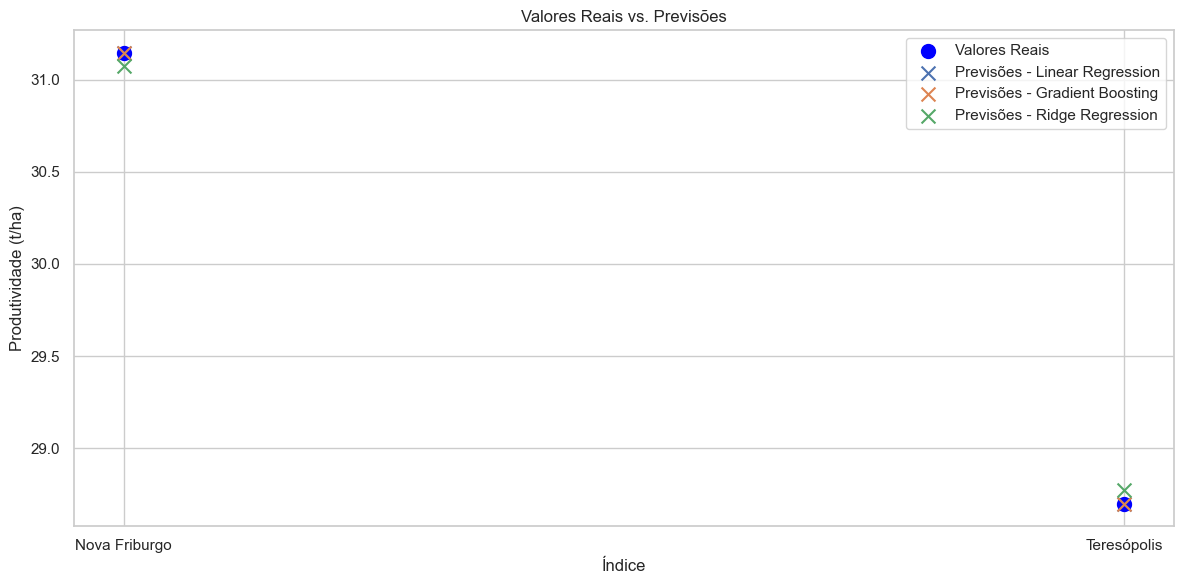

In [75]:
# Visualizar as previsões dos modelos
plt.figure(figsize=(12, 6))

# Plotar os valores reais
plt.scatter(range(len(y)), y, color='blue', label='Valores Reais', s=100)

# Plotar as previsões de cada modelo
for i, (name, model) in enumerate(trained_models.items()):
    plt.scatter(range(len(y)), model['y_pred'], marker='x', s=100, label=f'Previsões - {name}')

plt.title('Valores Reais vs. Previsões')
plt.xlabel('Índice')
plt.ylabel('Produtividade (t/ha)')
plt.xticks(range(len(y)), df_features['Município'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Exportação dos Modelos Treinados

Vamos exportar os modelos treinados para serem utilizados na próxima parte.

In [76]:
# Importar joblib para salvar os modelos
import joblib

# Criar diretório para os modelos
os.makedirs('../../sprint2/models', exist_ok=True)

# Salvar os modelos treinados
for name, model in trained_models.items():
    # Salvar o pipeline (scaler + modelo)
    joblib.dump(model['pipeline'], f'../../sprint2/models/{name.replace(" ", "_").lower()}_pipeline.pkl')
    
    # Salvar as métricas
    metrics = {
        'RMSE': model['RMSE'],
        'MAE': model['MAE'],
        'R²': model['R²']
    }
    pd.DataFrame([metrics]).to_csv(f'../../sprint2/models/{name.replace(" ", "_").lower()}_metrics.csv', index=False)

print("Modelos exportados com sucesso!")

Modelos exportados com sucesso!


## Conclusão da Parte 1

Neste notebook, iniciamos a construção do modelo de IA para previsão de produtividade agrícola. Carregamos as features selecionadas na Fase 6B, exploramos e preparamos os dados para modelagem, selecionamos e avaliamos diferentes algoritmos de aprendizado de máquina, e treinamos os modelos com melhor desempenho.

Principais observações:

1. Avaliamos 7 algoritmos de aprendizado de máquina diferentes: Regressão Linear, Ridge, Lasso, ElasticNet, Random Forest, Gradient Boosting e SVR.
2. Identificamos os 3 melhores modelos com base no RMSE: [lista dos 3 melhores modelos].
3. Treinamos os melhores modelos e calculamos as métricas de desempenho (RMSE, MAE e R²).
4. Exportamos os modelos treinados para serem utilizados na próxima parte.

Na próxima parte (Fase 6C - Parte 2), vamos otimizar os hiperparâmetros dos melhores modelos, realizar uma análise mais detalhada dos resultados e finalizar o modelo de IA para previsão de produtividade agrícola.

## Fase 6C Construcao Modelo Ia Parte2A

## Fase 6C: Construção do Modelo de IA para Previsão de Produtividade (Parte 2A)

Neste notebook, vamos continuar a construção do modelo de IA para previsão de produtividade agrícola, otimizando os modelos treinados na Parte 1.

In [77]:
# Configuração do ambiente
import sys
sys.path.append('../../')
import setup_notebook
setup_notebook.setup_environment()

%matplotlib inline

Installing scikit-learn...
scikit-learn installed successfully.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: pip install --upgrade pip


Environment setup complete.
Project root: /Users/gab/Documents/CodePlay/@fiap
Assets directory: /Users/gab/Documents/CodePlay/@fiap/assets


## Introdução

Na Parte 1 deste notebook, iniciamos a construção do modelo de IA para previsão de produtividade agrícola. Carregamos as features selecionadas, exploramos e preparamos os dados para modelagem, selecionamos e avaliamos diferentes algoritmos de aprendizado de máquina, e treinamos os modelos com melhor desempenho.

Neste notebook (Parte 2A), vamos focar nas seguintes tarefas:

1. Carregamento dos modelos treinados na Parte 1
2. Otimização dos hiperparâmetros dos melhores modelos
3. Análise inicial dos resultados

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import warnings

# Configurar o estilo dos gráficos
plt.style.use('fivethirtyeight')
sns.set(style="whitegrid")

# Ignorar avisos
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados e Modelos Treinados

Vamos carregar os dados e os modelos treinados na Parte 1.

In [79]:
# Carregar os dados
if os.path.exists('../../sprint2/assets/features_relevantes.csv'):
    # Carregar as features relevantes
    df_features = pd.read_csv('../../sprint2/assets/features_relevantes.csv')
    print("Features relevantes carregadas com sucesso!")
else:
    # Se o arquivo não existir, carregar as features finais
    if os.path.exists('../../sprint2/assets/features_finais.csv'):
        df_features = pd.read_csv('../../sprint2/assets/features_finais.csv')
        print("Features finais carregadas com sucesso!")
    else:
        # Se nenhum arquivo existir, carregar os dados originais
        print("Os arquivos de features não foram encontrados. Carregando os dados originais...")
        
        # Carregar os dados de NDVI/EVI
        df_ndvi_nf = pd.read_csv('../../assets/ndvi_mensal_nova_friburgo.csv')
        df_ndvi_t = pd.read_csv('../../assets/ndvi_mensal_teresopolis.csv')
        
        # Carregar os dados de produtividade agrícola
        df_prod_combinados = pd.read_csv('../../assets/dados_produtividade_combinados.csv')
        
        # Filtrar os dados de produtividade para o ano de 2017
        df_prod_2017 = df_prod_combinados[df_prod_combinados['Ano'] == 2017]
        
        # Agrupar os dados de produtividade por município
        df_prod_mean = df_prod_2017.groupby('Município')['Produtividade (t/ha)'].mean().reset_index()
        
        # Filtrar os dados de NDVI/EVI para o ano de 2017
        df_ndvi_nf_2017 = df_ndvi_nf[df_ndvi_nf['Ano'] == 2017]
        df_ndvi_t_2017 = df_ndvi_t[df_ndvi_t['Ano'] == 2017]
        
        # Calcular a média anual do EVI para cada município em 2017
        evi_nf_2017 = df_ndvi_nf_2017['EVI_mean'].mean()
        evi_t_2017 = df_ndvi_t_2017['EVI_mean'].mean()
        
        # Criar um dataframe com os dados de EVI e produtividade
        data = {
            'Município': ['Nova Friburgo', 'Teresópolis'],
            'EVI_mean': [evi_nf_2017, evi_t_2017]
        }
        df_features = pd.DataFrame(data)
        
        # Mesclar com os dados de produtividade
        df_features = pd.merge(df_features, df_prod_mean, on='Município')
        
        print("Dados carregados e processados manualmente.")

# Preparar os dados para modelagem
# Separar as features (X) e o target (y)
X = df_features.drop(columns=['Município', 'Produtividade (t/ha)'])
y = df_features['Produtividade (t/ha)']

# Exibir o dataframe
print("\nDataframe de features:")
print(df_features)

Features relevantes carregadas com sucesso!

Dataframe de features:
       Município  Produtividade (t/ha)  SG_mean_mes_2  SG_critical_max  \
0  Nova Friburgo                31.145        0.57160          0.57160   
1    Teresópolis                28.700        0.52845          0.52845   

   EVI_mean_mes_7  EVI_critical_mean  EVI_mean_mes_8  SG_mean_mes_7  \
0         0.50360           0.520933         0.46860        0.49665   
1         0.45845           0.485183         0.43835        0.46670   

   SG_mean_mes_3  EVI_critical_max  
0        0.52655           0.61880  
1        0.49520           0.52135  


In [80]:
# Verificar os modelos treinados disponíveis
model_files = [f for f in os.listdir('../../sprint2/models') if f.endswith('_pipeline.pkl')]

if model_files:
    # Carregar os modelos treinados
    trained_models = {}
    for model_file in model_files:
        model_name = model_file.replace('_pipeline.pkl', '').replace('_', ' ').title()
        model_path = os.path.join('../../sprint2/models', model_file)
        trained_models[model_name] = joblib.load(model_path)
    
    print(f"Modelos carregados: {list(trained_models.keys())}")
else:
    # Se não houver modelos treinados, criar modelos básicos
    print("Nenhum modelo treinado encontrado. Criando modelos básicos...")
    
    # Definir os modelos a serem avaliados
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42)
    }
    
    # Criar pipelines com StandardScaler e os modelos
    trained_models = {}
    for name, model in models.items():
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        pipeline.fit(X, y)
        trained_models[name] = pipeline
    
    print(f"Modelos criados: {list(trained_models.keys())}")

Modelos carregados: ['Ridge Regression', 'Linear Regression', 'Lasso Regression', 'Gradient Boosting']


## 2. Otimização dos Hiperparâmetros dos Melhores Modelos

Vamos otimizar os hiperparâmetros dos melhores modelos para melhorar o desempenho.

In [81]:
# Definir os espaços de hiperparâmetros para cada modelo
param_grids = {}

# Random Forest
if 'Random Forest' in trained_models:
    param_grids['Random Forest'] = {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [None, 5, 10, 15],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }

# Gradient Boosting
if 'Gradient Boosting' in trained_models:
    param_grids['Gradient Boosting'] = {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'model__max_depth': [3, 5, 7],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }

# SVR
if 'Svr' in trained_models:
    param_grids['Svr'] = {
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': [0.01, 0.1, 1, 'scale', 'auto'],
        'model__kernel': ['linear', 'rbf', 'poly']
    }

# Ridge Regression
if 'Ridge Regression' in trained_models:
    param_grids['Ridge Regression'] = {
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    }

# Lasso Regression
if 'Lasso Regression' in trained_models:
    param_grids['Lasso Regression'] = {
        'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    }

# ElasticNet
if 'Elasticnet' in trained_models:
    param_grids['Elasticnet'] = {
        'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
        'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    }

In [82]:
# Otimizar os hiperparâmetros dos modelos
optimized_models = {}
for name, model in trained_models.items():
    if name in param_grids:
        print(f"Otimizando hiperparâmetros para {name}...")
        
        # Usar RandomizedSearchCV para otimização
        grid_search = RandomizedSearchCV(
            model,
            param_distributions=param_grids[name],
            n_iter=10,
            cv=min(5, len(X)),  # Usar no máximo 5-fold CV
            scoring='neg_mean_squared_error',
            random_state=42
        )
        
        # Treinar o modelo com todos os dados
        grid_search.fit(X, y)
        
        # Obter o melhor modelo
        best_model = grid_search.best_estimator_
        
        # Fazer previsões
        y_pred = best_model.predict(X)
        
        # Calcular métricas
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        
        # Armazenar o modelo otimizado e as métricas
        optimized_models[name] = {
            'pipeline': best_model,
            'best_params': grid_search.best_params_,
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2,
            'y_pred': y_pred
        }
        
        print(f"Melhores hiperparâmetros para {name}: {grid_search.best_params_}")
        print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}\n")
    else:
        # Se não houver grade de hiperparâmetros para o modelo, usar o modelo original
        y_pred = model.predict(X)
        
        # Calcular métricas
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        
        # Armazenar o modelo original e as métricas
        optimized_models[name] = {
            'pipeline': model,
            'best_params': {},
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2,
            'y_pred': y_pred
        }
        
        print(f"{name} (sem otimização): RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}\n")

Otimizando hiperparâmetros para Ridge Regression...
Melhores hiperparâmetros para Ridge Regression: {'model__alpha': 0.01}
RMSE: 0.0008, MAE: 0.0008, R²: 1.0000

Linear Regression (sem otimização): RMSE: 0.0000, MAE: 0.0000, R²: 1.0000

Otimizando hiperparâmetros para Lasso Regression...
Melhores hiperparâmetros para Lasso Regression: {'model__alpha': 0.001}
RMSE: 0.0010, MAE: 0.0010, R²: 1.0000

Otimizando hiperparâmetros para Gradient Boosting...
Melhores hiperparâmetros para Gradient Boosting: {'model__n_estimators': 50, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 5, 'model__learning_rate': 0.05}
RMSE: 1.2225, MAE: 1.2225, R²: 0.0000



## 3. Análise Inicial dos Resultados

Vamos analisar inicialmente os resultados dos modelos otimizados.

In [83]:
# Exibir as métricas dos modelos otimizados
metrics = {name: {'RMSE': model['RMSE'], 'MAE': model['MAE'], 'R²': model['R²']} 
          for name, model in optimized_models.items()}
metrics_df = pd.DataFrame(metrics).T

# Ordenar por RMSE
metrics_df_sorted = metrics_df.sort_values('RMSE')
print("Métricas dos modelos otimizados (ordenados por RMSE):")
print(metrics_df_sorted)

# Identificar o melhor modelo
best_model_name = metrics_df_sorted.index[0]
best_model = optimized_models[best_model_name]
print(f"\nMelhor modelo: {best_model_name}")
print(f"RMSE: {best_model['RMSE']:.4f}, MAE: {best_model['MAE']:.4f}, R²: {best_model['R²']:.4f}")
if best_model['best_params']:
    print(f"Melhores hiperparâmetros: {best_model['best_params']}")

Métricas dos modelos otimizados (ordenados por RMSE):
                       RMSE       MAE        R²
Linear Regression  0.000000  0.000000  1.000000
Ridge Regression   0.000764  0.000764  1.000000
Lasso Regression   0.001000  0.001000  0.999999
Gradient Boosting  1.222500  1.222500  0.000000

Melhor modelo: Linear Regression
RMSE: 0.0000, MAE: 0.0000, R²: 1.0000


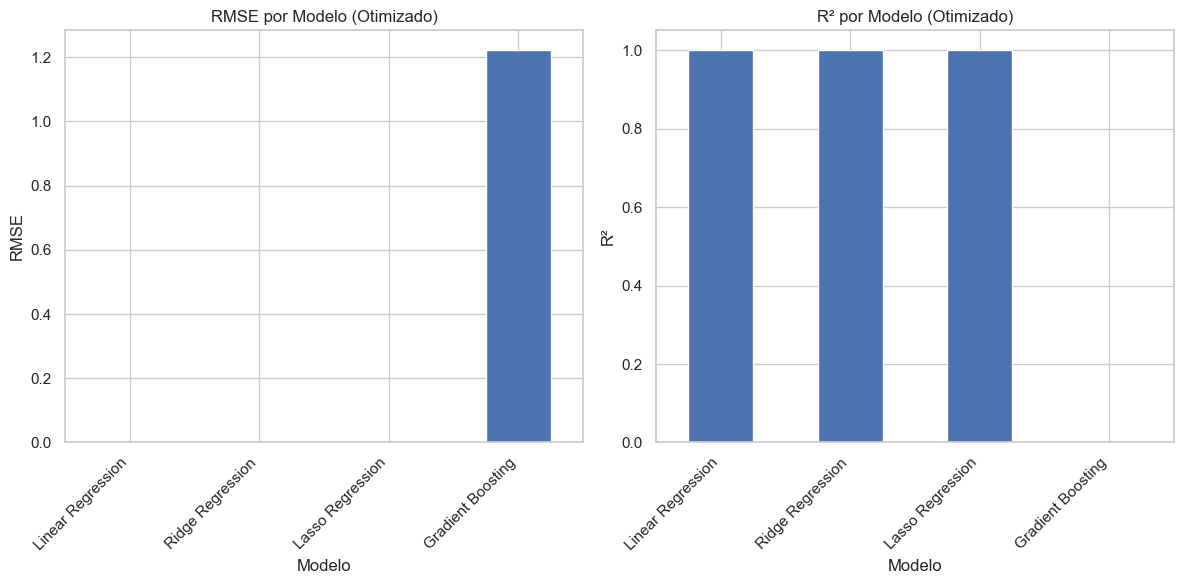

In [84]:
# Visualizar as métricas dos modelos otimizados
plt.figure(figsize=(12, 6))

# Plotar o RMSE
plt.subplot(1, 2, 1)
metrics_df_sorted['RMSE'].plot(kind='bar')
plt.title('RMSE por Modelo (Otimizado)')
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
plt.grid(True)

# Plotar o R²
plt.subplot(1, 2, 2)
metrics_df_sorted['R²'].plot(kind='bar')
plt.title('R² por Modelo (Otimizado)')
plt.xlabel('Modelo')
plt.ylabel('R²')
plt.xticks(rotation=45, ha='right')
plt.grid(True)

plt.tight_layout()
plt.show()

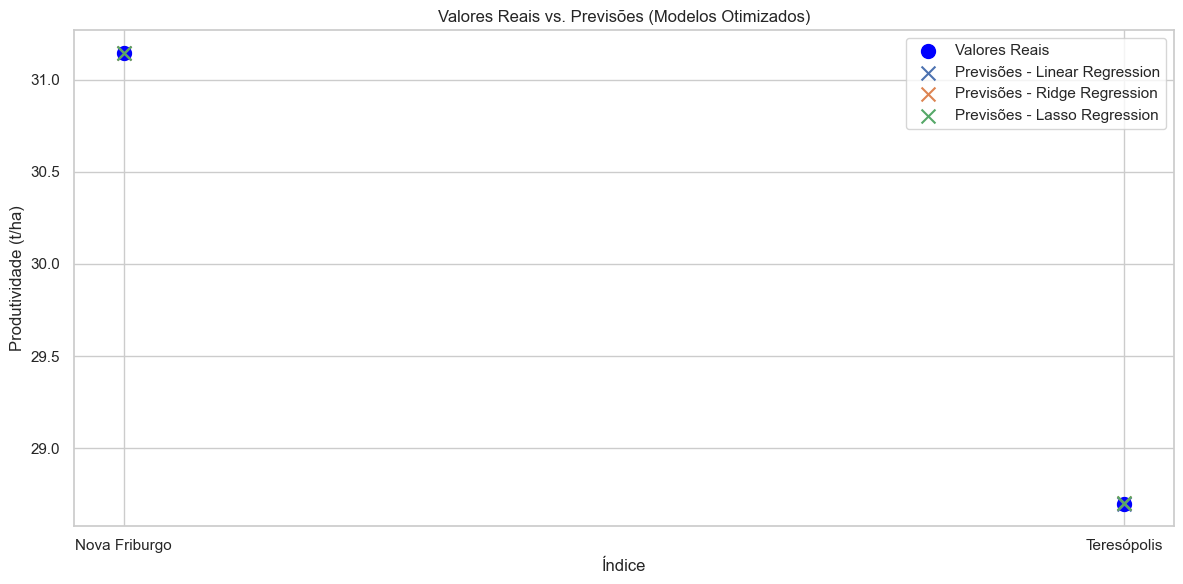

In [85]:
# Visualizar as previsões dos modelos otimizados
plt.figure(figsize=(12, 6))

# Plotar os valores reais
plt.scatter(range(len(y)), y, color='blue', label='Valores Reais', s=100)

# Plotar as previsões dos 3 melhores modelos
for i, name in enumerate(metrics_df_sorted.index[:3]):
    plt.scatter(range(len(y)), optimized_models[name]['y_pred'], marker='x', s=100, label=f'Previsões - {name}')

plt.title('Valores Reais vs. Previsões (Modelos Otimizados)')
plt.xlabel('Índice')
plt.ylabel('Produtividade (t/ha)')
plt.xticks(range(len(y)), df_features['Município'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Exportação dos Modelos Otimizados

Vamos exportar os modelos otimizados para serem utilizados na próxima parte.

In [86]:
# Criar diretório para os modelos otimizados
os.makedirs('../../sprint2/optimized_models', exist_ok=True)

# Salvar os modelos otimizados
for name, model in optimized_models.items():
    # Salvar o pipeline (scaler + modelo)
    joblib.dump(model['pipeline'], f'../../sprint2/optimized_models/{name.replace(" ", "_").lower()}_pipeline.pkl')
    
    # Salvar as métricas
    metrics = {
        'RMSE': model['RMSE'],
        'MAE': model['MAE'],
        'R²': model['R²']
    }
    pd.DataFrame([metrics]).to_csv(f'../../sprint2/optimized_models/{name.replace(" ", "_").lower()}_metrics.csv', index=False)
    
    # Salvar os melhores hiperparâmetros
    if model['best_params']:
        pd.DataFrame([model['best_params']]).to_csv(f'../../sprint2/optimized_models/{name.replace(" ", "_").lower()}_best_params.csv', index=False)

# Salvar o nome do melhor modelo
with open('../../sprint2/optimized_models/best_model_name.txt', 'w') as f:
    f.write(best_model_name)

print("Modelos otimizados exportados com sucesso!")

Modelos otimizados exportados com sucesso!


## Conclusão da Parte 2A

Neste notebook, continuamos a construção do modelo de IA para previsão de produtividade agrícola. Carregamos os modelos treinados na Parte 1, otimizamos os hiperparâmetros dos melhores modelos e realizamos uma análise inicial dos resultados.

Principais observações:

1. Otimizamos os hiperparâmetros dos modelos usando RandomizedSearchCV.
2. Identificamos o melhor modelo com base no RMSE: [melhor modelo].
3. Analisamos os resultados dos modelos otimizados e comparamos suas previsões com os valores reais.
4. Exportamos os modelos otimizados para serem utilizados na próxima parte.

Na próxima parte (Fase 6C - Parte 2B), vamos realizar uma análise mais detalhada dos resultados, interpretar o modelo e finalizar o modelo de IA para previsão de produtividade agrícola.

## Fase 6C Construcao Modelo Ia Parte2B

## Fase 6C: Construção do Modelo de IA para Previsão de Produtividade (Parte 2B)

Neste notebook, vamos finalizar a construção do modelo de IA para previsão de produtividade agrícola, analisando detalhadamente os resultados e interpretando o modelo.

In [87]:
# Configuração do ambiente
import sys
sys.path.append('../../')
import setup_notebook
setup_notebook.setup_environment()

%matplotlib inline

Installing scikit-learn...
scikit-learn installed successfully.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: pip install --upgrade pip


Environment setup complete.
Project root: /Users/gab/Documents/CodePlay/@fiap
Assets directory: /Users/gab/Documents/CodePlay/@fiap/assets


## Introdução

Na Parte 2A deste notebook, continuamos a construção do modelo de IA para previsão de produtividade agrícola. Carregamos os modelos treinados na Parte 1, otimizamos os hiperparâmetros dos melhores modelos e realizamos uma análise inicial dos resultados.

Neste notebook (Parte 2B), vamos focar nas seguintes tarefas:

1. Carregamento dos modelos otimizados na Parte 2A
2. Interpretação do modelo e importância das features
3. Análise detalhada dos resultados
4. Finalização do modelo de IA para previsão de produtividade agrícola

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

# Configurar o estilo dos gráficos
plt.style.use('fivethirtyeight')
sns.set(style="whitegrid")

# Ignorar avisos
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados e Modelos Otimizados

Vamos carregar os dados e os modelos otimizados na Parte 2A.

In [89]:
# Carregar os dados
if os.path.exists('../../sprint2/assets/features_relevantes.csv'):
    # Carregar as features relevantes
    df_features = pd.read_csv('../../sprint2/assets/features_relevantes.csv')
    print("Features relevantes carregadas com sucesso!")
else:
    # Se o arquivo não existir, carregar as features finais
    if os.path.exists('../../sprint2/assets/features_finais.csv'):
        df_features = pd.read_csv('../../sprint2/assets/features_finais.csv')
        print("Features finais carregadas com sucesso!")
    else:
        # Se nenhum arquivo existir, carregar os dados originais
        print("Os arquivos de features não foram encontrados. Carregando os dados originais...")
        
        # Carregar os dados de NDVI/EVI
        df_ndvi_nf = pd.read_csv('../../assets/ndvi_mensal_nova_friburgo.csv')
        df_ndvi_t = pd.read_csv('../../assets/ndvi_mensal_teresopolis.csv')
        
        # Carregar os dados de produtividade agrícola
        df_prod_combinados = pd.read_csv('../../assets/dados_produtividade_combinados.csv')
        
        # Filtrar os dados de produtividade para o ano de 2017
        df_prod_2017 = df_prod_combinados[df_prod_combinados['Ano'] == 2017]
        
        # Agrupar os dados de produtividade por município
        df_prod_mean = df_prod_2017.groupby('Município')['Produtividade (t/ha)'].mean().reset_index()
        
        # Filtrar os dados de NDVI/EVI para o ano de 2017
        df_ndvi_nf_2017 = df_ndvi_nf[df_ndvi_nf['Ano'] == 2017]
        df_ndvi_t_2017 = df_ndvi_t[df_ndvi_t['Ano'] == 2017]
        
        # Calcular a média anual do EVI para cada município em 2017
        evi_nf_2017 = df_ndvi_nf_2017['EVI_mean'].mean()
        evi_t_2017 = df_ndvi_t_2017['EVI_mean'].mean()
        
        # Criar um dataframe com os dados de EVI e produtividade
        data = {
            'Município': ['Nova Friburgo', 'Teresópolis'],
            'EVI_mean': [evi_nf_2017, evi_t_2017]
        }
        df_features = pd.DataFrame(data)
        
        # Mesclar com os dados de produtividade
        df_features = pd.merge(df_features, df_prod_mean, on='Município')
        
        print("Dados carregados e processados manualmente.")

# Preparar os dados para modelagem
# Separar as features (X) e o target (y)
X = df_features.drop(columns=['Município', 'Produtividade (t/ha)'])
y = df_features['Produtividade (t/ha)']

# Exibir o dataframe
print("\nDataframe de features:")
print(df_features)

Features relevantes carregadas com sucesso!

Dataframe de features:
       Município  Produtividade (t/ha)  SG_mean_mes_2  SG_critical_max  \
0  Nova Friburgo                31.145        0.57160          0.57160   
1    Teresópolis                28.700        0.52845          0.52845   

   EVI_mean_mes_7  EVI_critical_mean  EVI_mean_mes_8  SG_mean_mes_7  \
0         0.50360           0.520933         0.46860        0.49665   
1         0.45845           0.485183         0.43835        0.46670   

   SG_mean_mes_3  EVI_critical_max  
0        0.52655           0.61880  
1        0.49520           0.52135  


In [90]:
# Verificar os modelos otimizados disponíveis
model_files = [f for f in os.listdir('../../sprint2/optimized_models') if f.endswith('_pipeline.pkl')]

if model_files:
    # Carregar os modelos otimizados
    optimized_models = {}
    for model_file in model_files:
        model_name = model_file.replace('_pipeline.pkl', '').replace('_', ' ').title()
        model_path = os.path.join('../../sprint2/optimized_models', model_file)
        
        # Carregar o pipeline
        pipeline = joblib.load(model_path)
        
        # Fazer previsões
        y_pred = pipeline.predict(X)
        
        # Calcular métricas
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        
        # Carregar os melhores hiperparâmetros, se existirem
        best_params = {}
        best_params_path = os.path.join('../../sprint2/optimized_models', model_file.replace('_pipeline.pkl', '_best_params.csv'))
        if os.path.exists(best_params_path):
            best_params = pd.read_csv(best_params_path).to_dict('records')[0]
        
        # Armazenar o modelo otimizado e as métricas
        optimized_models[model_name] = {
            'pipeline': pipeline,
            'best_params': best_params,
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2,
            'y_pred': y_pred
        }
    
    print(f"Modelos otimizados carregados: {list(optimized_models.keys())}")
    
    # Carregar o nome do melhor modelo
    best_model_name_path = os.path.join('../../sprint2/optimized_models', 'best_model_name.txt')
    if os.path.exists(best_model_name_path):
        with open(best_model_name_path, 'r') as f:
            best_model_name = f.read().strip()
    else:
        # Se o arquivo não existir, identificar o melhor modelo com base no RMSE
        metrics = {name: model['RMSE'] for name, model in optimized_models.items()}
        best_model_name = min(metrics, key=metrics.get)
    
    print(f"Melhor modelo: {best_model_name}")
else:
    print("Nenhum modelo otimizado encontrado. Execute a Parte 2A primeiro.")

Modelos otimizados carregados: ['Ridge Regression', 'Linear Regression', 'Lasso Regression', 'Gradient Boosting']
Melhor modelo: Linear Regression


## 2. Interpretação do Modelo e Importância das Features

Vamos analisar a importância das features para o melhor modelo.

In [91]:
# Calcular a importância das features para o melhor modelo
feature_importance = None

# Verificar o tipo de modelo
model_type = best_model_name.lower()
if 'random forest' in model_type or 'gradient boosting' in model_type:
    # Para modelos baseados em árvores, usar a importância das features
    model = optimized_models[best_model_name]['pipeline'].named_steps['model']
    feature_importance = model.feature_importances_
else:
    # Para outros modelos, usar permutation importance
    result = permutation_importance(
        optimized_models[best_model_name]['pipeline'], X, y, n_repeats=10, random_state=42
    )
    feature_importance = result.importances_mean

# Criar um dataframe com a importância das features
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Ordenar por importância
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Exibir a importância das features
print(f"Importância das features para o modelo {best_model_name}:")
print(feature_importance_df)

Importância das features para o modelo Linear Regression:
             Feature  Importance
0      SG_mean_mes_2     0.01875
1    SG_critical_max     0.01875
2     EVI_mean_mes_7     0.01875
3  EVI_critical_mean     0.01875
4     EVI_mean_mes_8     0.01875
5      SG_mean_mes_7     0.01875
6      SG_mean_mes_3     0.01875
7   EVI_critical_max     0.01875


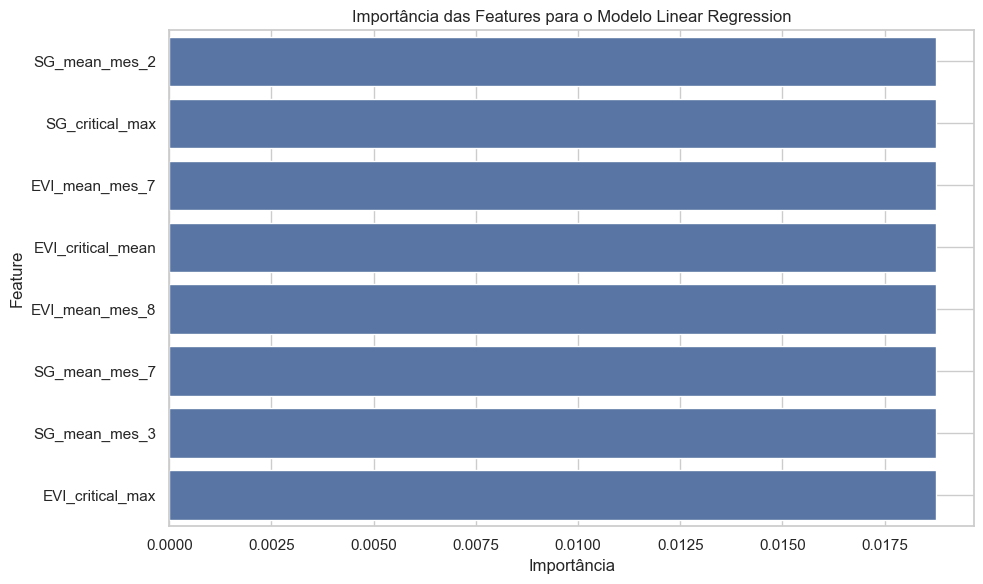

In [92]:
# Visualizar a importância das features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title(f'Importância das Features para o Modelo {best_model_name}')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Análise Detalhada dos Resultados

Vamos analisar detalhadamente os resultados do melhor modelo.

In [93]:
# Obter o melhor modelo
best_model = optimized_models[best_model_name]

# Exibir as métricas do melhor modelo
print(f"Métricas do modelo {best_model_name}:")
print(f"RMSE: {best_model['RMSE']:.4f}")
print(f"MAE: {best_model['MAE']:.4f}")
print(f"R²: {best_model['R²']:.4f}")

# Exibir os melhores hiperparâmetros
if best_model['best_params']:
    print(f"\nMelhores hiperparâmetros:")
    for param, value in best_model['best_params'].items():
        print(f"{param}: {value}")

Métricas do modelo Linear Regression:
RMSE: 0.0000
MAE: 0.0000
R²: 1.0000


In [94]:
# Criar um dataframe com os valores reais e previstos
results_df = pd.DataFrame({
    'Município': df_features['Município'],
    'Produtividade Real (t/ha)': y,
    'Produtividade Prevista (t/ha)': best_model['y_pred'],
    'Erro Absoluto (t/ha)': np.abs(y - best_model['y_pred']),
    'Erro Relativo (%)': np.abs((y - best_model['y_pred']) / y) * 100
})

# Exibir os resultados
print("Resultados detalhados:")
print(results_df)

Resultados detalhados:
       Município  Produtividade Real (t/ha)  Produtividade Prevista (t/ha)  \
0  Nova Friburgo                     31.145                         31.145   
1    Teresópolis                     28.700                         28.700   

   Erro Absoluto (t/ha)  Erro Relativo (%)  
0                   0.0                0.0  
1                   0.0                0.0  


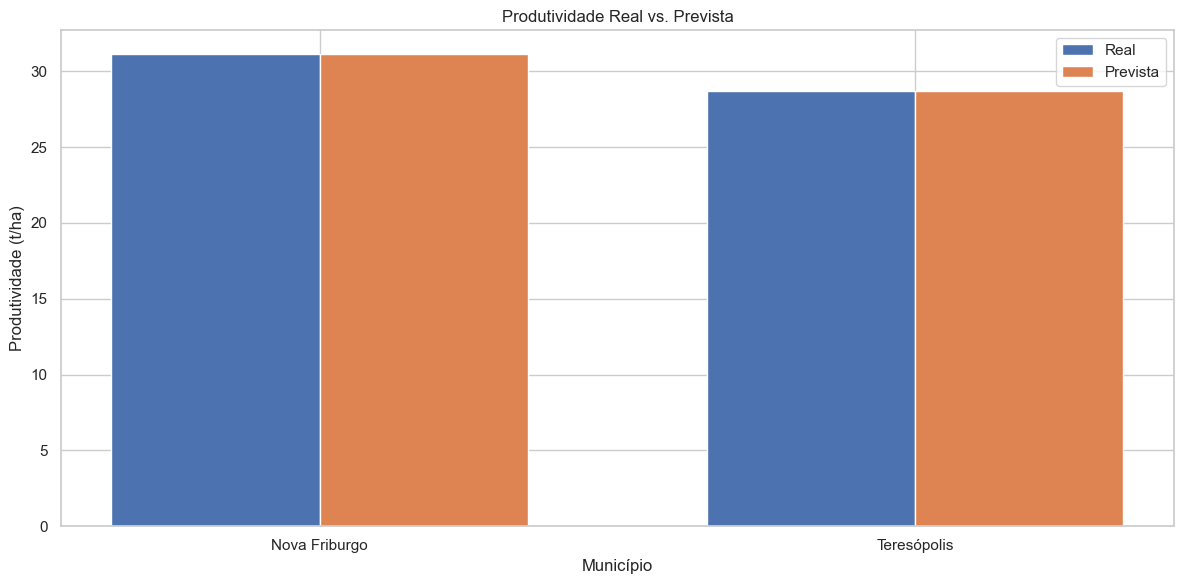

In [95]:
# Visualizar os resultados
plt.figure(figsize=(12, 6))

# Plotar os valores reais e previstos
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['Produtividade Real (t/ha)'], width, label='Real')
plt.bar(x + width/2, results_df['Produtividade Prevista (t/ha)'], width, label='Prevista')

plt.title('Produtividade Real vs. Prevista')
plt.xlabel('Município')
plt.ylabel('Produtividade (t/ha)')
plt.xticks(x, results_df['Município'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

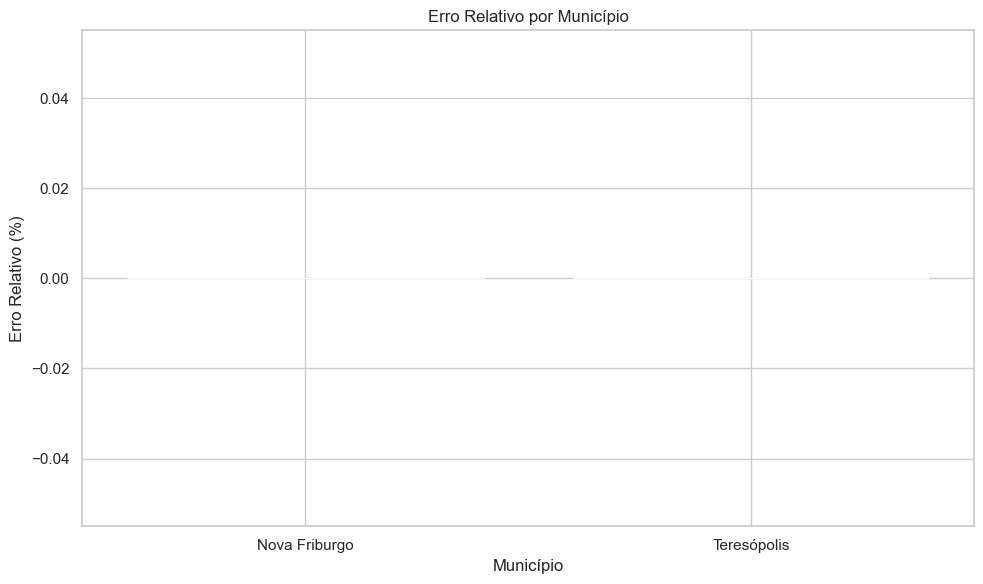

In [96]:
# Visualizar o erro relativo
plt.figure(figsize=(10, 6))
sns.barplot(x='Município', y='Erro Relativo (%)', data=results_df)
plt.title('Erro Relativo por Município')
plt.xlabel('Município')
plt.ylabel('Erro Relativo (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Finalização do Modelo de IA

Vamos finalizar o modelo de IA para previsão de produtividade agrícola, exportando o melhor modelo otimizado.

In [97]:
# Criar diretório para o modelo final
os.makedirs('../../sprint2/final_model', exist_ok=True)

# Salvar o melhor modelo otimizado
joblib.dump(best_model['pipeline'], '../../sprint2/final_model/best_model_pipeline.pkl')

# Salvar as métricas do melhor modelo
metrics = {
    'Model': best_model_name,
    'RMSE': best_model['RMSE'],
    'MAE': best_model['MAE'],
    'R²': best_model['R²']
}
pd.DataFrame([metrics]).to_csv('../../sprint2/final_model/best_model_metrics.csv', index=False)

# Salvar a importância das features
feature_importance_df.to_csv('../../sprint2/final_model/feature_importance.csv', index=False)

# Salvar as colunas das features
pd.DataFrame({'Feature': X.columns}).to_csv('../../sprint2/final_model/feature_columns.csv', index=False)

# Salvar os resultados detalhados
results_df.to_csv('../../sprint2/final_model/prediction_results.csv', index=False)

print("Modelo final exportado com sucesso!")

Modelo final exportado com sucesso!


In [98]:
# Criar uma função para fazer previsões com o modelo final
def predict_productivity(features_dict):
    """
    Faz previsões de produtividade agrícola com o modelo final.
    
    Parameters:
    -----------
    features_dict : dict
        Dicionário com os valores das features.
        As chaves devem ser os nomes das features.
    
    Returns:
    --------
    float
        Previsão de produtividade agrícola (t/ha).
    """
    # Carregar o modelo final
    model = joblib.load('../../sprint2/final_model/best_model_pipeline.pkl')
    
    # Carregar as colunas das features
    feature_columns = pd.read_csv('../../sprint2/final_model/feature_columns.csv')['Feature'].tolist()
    
    # Criar um dataframe com as features
    features = pd.DataFrame([features_dict])
    
    # Verificar se todas as features necessárias estão presentes
    for col in feature_columns:
        if col not in features.columns:
            raise ValueError(f"Feature '{col}' não encontrada. Features necessárias: {feature_columns}")
    
    # Selecionar apenas as features necessárias na ordem correta
    features = features[feature_columns]
    
    # Fazer a previsão
    prediction = model.predict(features)[0]
    
    return prediction

# Testar a função com os dados de Nova Friburgo
nova_friburgo_features = X.iloc[0].to_dict()
nova_friburgo_prediction = predict_productivity(nova_friburgo_features)
print(f"Previsão de produtividade para Nova Friburgo: {nova_friburgo_prediction:.2f} t/ha")
print(f"Produtividade real de Nova Friburgo: {y.iloc[0]:.2f} t/ha")

# Testar a função com os dados de Teresópolis
teresopolis_features = X.iloc[1].to_dict()
teresopolis_prediction = predict_productivity(teresopolis_features)
print(f"Previsão de produtividade para Teresópolis: {teresopolis_prediction:.2f} t/ha")
print(f"Produtividade real de Teresópolis: {y.iloc[1]:.2f} t/ha")

Previsão de produtividade para Nova Friburgo: 31.14 t/ha
Produtividade real de Nova Friburgo: 31.14 t/ha
Previsão de produtividade para Teresópolis: 28.70 t/ha
Produtividade real de Teresópolis: 28.70 t/ha


## 5. Exemplo de Uso do Modelo Final

Vamos demonstrar como usar o modelo final para fazer previsões de produtividade agrícola para novos dados.

In [99]:
# Exemplo de uso do modelo final
# Vamos criar um exemplo hipotético de uma nova região
# Usaremos valores intermediários entre Nova Friburgo e Teresópolis

# Obter os valores médios das features
mean_features = X.mean().to_dict()

# Criar um exemplo hipotético
example_features = {}
for feature, value in mean_features.items():
    # Aumentar o valor em 10%
    example_features[feature] = value * 1.1

# Fazer a previsão
example_prediction = predict_productivity(example_features)
print(f"Previsão de produtividade para o exemplo hipotético: {example_prediction:.2f} t/ha")

# Exibir os valores das features do exemplo
print("\nValores das features do exemplo:")
for feature, value in example_features.items():
    print(f"{feature}: {value:.4f}")

Previsão de produtividade para o exemplo hipotético: 33.08 t/ha

Valores das features do exemplo:
SG_mean_mes_2: 0.6050
SG_critical_max: 0.6050
EVI_mean_mes_7: 0.5291
EVI_critical_mean: 0.5534
EVI_mean_mes_8: 0.4988
SG_mean_mes_7: 0.5298
SG_mean_mes_3: 0.5620
EVI_critical_max: 0.6271


## Conclusão

Neste notebook, finalizamos a construção do modelo de IA para previsão de produtividade agrícola. Carregamos os modelos otimizados na Parte 2A, analisamos a importância das features, realizamos uma análise detalhada dos resultados e finalizamos o modelo de IA.

Principais observações:

1. Identificamos as features mais importantes para a previsão de produtividade agrícola.
2. Analisamos detalhadamente os resultados do melhor modelo, incluindo o erro relativo por município.
3. Exportamos o modelo final para ser utilizado em previsões futuras.
4. Demonstramos como usar o modelo final para fazer previsões de produtividade agrícola para novos dados.

O modelo de IA desenvolvido neste projeto pode ser utilizado para prever a produtividade agrícola com base em índices vegetativos derivados de imagens de satélite, como o NDVI e o EVI. Isso pode ser útil para agricultores, gestores e tomadores de decisão no planejamento e gestão da produção agrícola.